## 0. Cadre Éthique & Apports de la Conférence Expert

### Synthèse de la conférence et ancrage dans l'audit

La conférence sur l'éthique des systèmes algorithmiques s'appuyait sur le cadre *AI4People* (Floridi et al.) et le Règlement européen sur l'IA (*AI Act*). Cinq principes éthiques y ont été définis pour une IA digne de confiance : **Bienfaisance**, **Non-malfaisance**, **Autonomie**, **Justice & Équité**, et **Explicabilité & Transparence**.

### Rappel de la tâche du modèle

Le modèle audité prédit la variable **`passed_next_stage`** (1 = candidat invité à l'entretien, 0 = écarté). Son rôle est de **trier les bons des mauvais CV** par rapport à un poste donné. Un audit d'équité dans ce contexte ne consiste donc *pas* à exiger des taux de sélection identiques entre groupes — ce qui serait absurde si les groupes ont des qualifications réellement différentes —, mais à vérifier que :

1. **À qualification égale**, les candidats sont traités de la même façon (Equal Opportunity : TPR égal entre groupes).
2. Les écarts de taux de sélection observés sont **expliqués par les compétences** plutôt que par des proxies de caractéristiques protégées (langues, distance, école).
3. Aucune feature sensible directe (âge, origine) n'influence la décision via le coefficient du modèle.

---

### Tableau de correspondance : Principes éthiques → Choix techniques de cet audit

| Principe éthique | Enjeu identifié en conférence | Traduction dans ce notebook |
|---|---|---|
| **Justice & Équité** | À qualification égale, traiter les candidats identiquement | **Equal Opportunity Difference (EOD)** comme métrique principale ; DP/DI utilisés en complément, en gardant à l'esprit que les *base rates* diffèrent |
| **Non-malfaisance** | Risque de dommage individuel / collectif / sociétal | Audit out-of-sample par attribut sensible ; tests Chi² séparés pour DP et EO ; comparaison aux base rates |
| **Explicabilité** | Éviter l'effet *black box* | §8 (coefficients L1), §8b (SHAP global + local), §11 (explication log-odds individuelle) |
| **Autonomie** | L'humain conserve le contrôle | Explication individuelle (§11) destinée au recruteur, conforme à l'Art. 14 AI Act |
| **Bienfaisance** | Recrutements équitables sans dégrader la pertinence du tri | Modèle équitable (§9–10) : suppression des features sensibles directes et proxies, comparaison avant/après sur ROC-AUC + EOD |

---

### Positionnement légal : AI Act — Système à haut risque

Conformément à l'**Annexe III de l'AI Act**, les outils automatisés de présélection de candidats en recrutement sont classés **systèmes à haut risque**. Les obligations qui s'imposent à LuxTalent sont :

- **Art. 9** — Système de gestion des risques documenté *(→ cet audit)*
- **Art. 10** — Gouvernance des données d'entraînement, détection et correction des biais *(→ Sections 4–9)*
- **Art. 13** — Transparence et fourniture d'informations aux déployeurs *(→ Sections 8b, 11)*
- **Art. 14** — Supervision humaine effective *(→ explications individuelles §11)*
- **Art. 15** — Exactitude, robustesse et cybersécurité

---

### Point clé : Intersectionnalité et discrimination indirecte

La conférence a insisté sur un risque souvent sous-estimé : l'**intersectionnalité**. Un modèle peut discriminer via la *combinaison* de caractéristiques, rendant la discrimination opaque. Deux croisements sont effectivement analysés en §7.4 :

- `age_group` × `fr_speaker` → tester si certaines combinaisons cumulent les désavantages au-delà de leurs effets marginaux
- `age_group` × `geo_group` → tester si l'âge interagit avec un proxy d'origine


# Audit d'Équité — Modèle de Classification de CVs

**Tâche du modèle :** prédire `passed_next_stage` ∈ {0, 1} — c'est-à-dire **trier les CV** entre candidats à inviter à l'entretien (1) et candidats à écarter (0).

**Objectif de l'audit :** vérifier que ce tri est équitable — c'est-à-dire qu'**à qualification égale**, les candidats sont traités identiquement quel que soit leur âge, leur origine présumée (langues, distance) ou leur école.

**Méthodologie :**
1. Identification des attributs sensibles et groupes protégés (§4)
2. Calcul des métriques d'équité **out-of-sample** (§5–6) :
   - Demographic Parity & Disparate Impact (sélection brute)
   - **Equal Opportunity** (sélection conditionnée sur la qualification réelle) ← métrique principale
3. Tests Chi² séparés pour DP et EO (§5b)
4. Analyse visuelle + intersectionnelle (§6, §7.4)
5. Stratégies correctives (§9) :
   - **Pre-processing** : suppression des features sensibles directes et proxies
   - **Post-processing** : calibration de seuil par groupe (présentée comme exploratoire — cf. avertissement légal)
   - *Note : `class_weight='balanced'` est utilisé pour stabiliser le déséquilibre 80/20, ce n'est pas une technique de fairness en soi.*
6. Explicabilité L1 + SHAP + log-odds individuel (§8, §8b, §11)
7. Comparaison ancien vs nouveau modèle sur le même test set (§10)

**Cadre légal de référence :**
- Directive européenne 2000/43/CE (non-discrimination)
- RGPD Art. 22 (décisions automatisées)
- AI Act (systèmes à haut risque : recrutement = Annexe III)
- Loi belge du 10 mai 2007 contre la discrimination


## 1. Imports & Configuration

In [1]:
import warnings

warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    precision_recall_curve, )

from imblearn.pipeline import Pipeline as ImbPipeline  # Utilisé pour cohérence avec le modèle d'origine

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

# Palette d'équité cohérente
FAIRNESS_COLORS = {'favorable': '#2ecc71', 'unfavorable': '#e74c3c', 'neutral': '#3498db'}

## 2. Chargement du Modèle et des Données

In [2]:
# Chargement du dataset
df = pd.read_csv('../data/cv_dataset.csv')
print(f'Dataset : {df.shape[0]} candidats, {df.shape[1]} colonnes')
print(f'Taux de sélection global : {df["passed_next_stage"].mean():.1%}')

# Chargement du modèle sauvegardé
import os

model_path = '../models/model_classification_cv_cool.joblib'
if os.path.exists(model_path):
    model_data = joblib.load(model_path)
    lr_pipeline = model_data['pipeline']
    best_threshold = model_data['optimal_threshold']
    print(f'Modèle chargé ✓  |  Seuil optimal : {best_threshold:.4f}')
else:
    raise FileNotFoundError

Dataset : 500 candidats, 21 colonnes
Taux de sélection global : 20.0%
Modèle chargé ✓  |  Seuil optimal : 0.1434


## 3. Feature Engineering & Prédictions sur le Dataset Complet

In [3]:
# Feature engineering identique au notebook de classification
df_audit = df.copy()

df_audit['avg_gap_duration'] = df_audit['total_gap_months'] / (df_audit['nb_gaps'] + 1)
df_audit['gap_ratio'] = df_audit['total_gap_months'] / (
        df_audit['total_experience_years'] * 12 + df_audit['total_gap_months'] + 1)
df_audit['skills_count'] = df_audit['skills'].fillna('').apply(
    lambda x: len([s.strip() for s in x.split(',') if s.strip()]))
df_audit['certif_count'] = df_audit['certifications'].fillna('').apply(
    lambda x: len([c.strip() for c in x.split(',') if c.strip()]))
df_audit['has_certif'] = (df_audit['certif_count'] > 0).astype(int)

# Nettoyage texte
for col in ['skills', 'certifications']:
    df_audit[col] = df_audit[col].fillna('').str.lower().str.replace(r'[^\w\s,]', '', regex=True)

X_full = df_audit.drop(columns=['cv_id', 'passed_next_stage'])
y_full = df_audit['passed_next_stage']

# ── Reproduction du split du modèle d'origine (random_state=42, stratify=y, test_size=0.2)
# pour disposer de prédictions OUT-OF-SAMPLE et éviter de gonfler les TPR/FPR
# par les données vues en entraînement.
idx_train, idx_test = train_test_split(
    np.arange(len(df_audit)),
    test_size=0.2, random_state=RANDOM_STATE,
    stratify=y_full,
)

# Probabilités sur tout le dataset (utilisées pour les visualisations descriptives)
df_audit['proba'] = lr_pipeline.predict_proba(X_full)[:, 1]
df_audit['pred'] = (df_audit['proba'] >= best_threshold).astype(int)

# Indicateur train/test pour pouvoir filtrer dans l'audit
df_audit['split'] = 'train'
df_audit.iloc[idx_test, df_audit.columns.get_loc('split')] = 'test'

# NB : df_audit_test sera (re)construit en Section 5 après l'ajout
# des colonnes de groupes — les groupes n'existent pas encore ici.

print(f'Prédictions calculées sur {len(df_audit)} candidats')
print(f'  • Train : {len(idx_train)}  |  Test : {len(idx_test)}')
print(f'Taux de sélection réel    (full)  : {y_full.mean():.1%}')
print(f'Taux de sélection prédit  (full)  : {df_audit["pred"].mean():.1%}')
print(
    f'Taux de sélection prédit  (test)  : {df_audit.loc[df_audit["split"] == "test", "pred"].mean():.1%}  ← utilisé pour l\'audit')


Prédictions calculées sur 500 candidats
  • Train : 400  |  Test : 100
Taux de sélection réel    (full)  : 20.0%
Taux de sélection prédit  (full)  : 33.0%
Taux de sélection prédit  (test)  : 34.0%  ← utilisé pour l'audit


## 4. Définition des Attributs Sensibles & Groupes Protégés

### Justification du choix des attributs

| Attribut | Risque | Base légale |
|---|---|---|
| `age` | Discrimination par âge (≤29 vs ≥35 ans) | Directive 2000/78/CE, Loi belge 2007 |
| `distance_ville_haute_km` | Proxy géographique / d'origine | RGPD Art. 9 (données pouvant révéler l'origine) |
| `lang_fr` (et autres langues) | Proxy de nationalité ou d'origine ethnique | Directive 2000/43/CE |
| `education_degree` | Discrimination socioéconomique indirecte (Master+ vs Bachelor) | AI Act Annexe III |
| `education_score` | Biais de prestige des institutions (école 4 vs école 3) | AI Act Art. 10 |

**Note :** Le dataset ne contient ni genre ni nationalité explicite, mais ces variables peuvent être présentes indirectement via des **proxies** (langues, distance, école).

**Note 2 :** `target_role` est volontairement ABSENT de cette table — le rôle visé est la définition du poste, pas un attribut protégé. Il est analysé séparément en §7.3.


In [4]:
# ── Création des groupes protégés ───────────────────────────────────────────

# Groupe 1 : Âge
df_audit['age_group'] = pd.cut(
    df_audit['age'],
    bins=[0, 29, 34, 100],
    labels=['Junior (≤29)', 'Mid (30-34)', 'Senior (≥35)']
)

# Groupe 2 : Proximité géographique
# distance_ville_haute_km — médiane ~4790 km (beaucoup sont très éloignés)
df_audit['geo_group'] = pd.cut(
    df_audit['distance_ville_haute_km'],
    bins=[0, 1000, 5000, 99999],
    labels=['Local (<1000km)', 'Régional (1-5000km)', 'International (>5000km)']
)

# Groupe 3 : Langue française (proxy d'intégration locale)
df_audit['fr_speaker'] = df_audit['lang_fr'].apply(
    lambda x: 'Francophone' if x >= 4 else 'Non-francophone'
)

# Groupe 4 : Niveau d'éducation
df_audit['edu_level'] = df_audit['education_degree'].apply(
    lambda x: 'Master+' if 'Master' in str(x) or 'PhD' in str(x) else 'Bachelor ou moins'
)

# Groupe 5 : Score éducation (école)
df_audit['edu_score_group'] = df_audit['education_score'].apply(
    lambda x: 'École de prestige (score 4)' if x >= 4 else 'École standard (score 3)'
)

print('Groupes définis :')
for col in ['age_group', 'geo_group', 'fr_speaker', 'edu_level', 'edu_score_group']:
    print(f'  {col} : {df_audit[col].value_counts().to_dict()}')

Groupes définis :
  age_group : {'Junior (≤29)': 181, 'Mid (30-34)': 178, 'Senior (≥35)': 141}
  geo_group : {'International (>5000km)': 211, 'Local (<1000km)': 159, 'Régional (1-5000km)': 130}
  fr_speaker : {'Non-francophone': 372, 'Francophone': 128}
  edu_level : {'Bachelor ou moins': 291, 'Master+': 209}
  edu_score_group : {'École standard (score 3)': 291, 'École de prestige (score 4)': 209}


## 5. Métriques d'Équité — Définitions & Calcul

### Métriques choisies et justification

| Métrique | Formule | Interprétation | Seuil d'alerte |
|---|---|---|---|
| **Selection rate par groupe** | P(Ŷ=1\|A=a) | Taux de candidats *prédits* sélectionnés dans le groupe | (référence) |
| **Base rate par groupe** | P(Y=1\|A=a) | Taux de candidats *réellement* qualifiés (label `passed_next_stage`) — sert de référence légitime | (descriptif) |
| **Demographic Parity Difference (DP Gap)** | max − min des selection rates | Écart de taux de sélection prédite — *à comparer aux base rates* | > 0.10, mais à interpréter avec précaution |
| **Disparate Impact Ratio (DI min)** | min / max des selection rates | Règle des 80% (jurisprudence US, mentionnée par AI Act) | < 0.80 = présomption à examiner |
| **Equal Opportunity Difference (EOD Gap)** | max − min des **TPR** | Écart entre groupes *à qualification égale* — **métrique principale** | > 0.10 |
| **TPR/FPR par groupe** | (visualisation) | Composantes de l'Equalized Odds | jugé visuellement §6 |

### Pourquoi l'EOD prime sur la DP/DI dans un contexte de tri de CV

La tâche du modèle est de **distinguer les candidats qualifiés des non-qualifiés**. Si le groupe A a en réalité 30% de candidats qualifiés et le groupe B en a 10%, un selection rate de 30%/10% est *attendu et légitime* — le modèle reflète la réalité des qualifications. La DP serait alors trompeuse.

L'**Equal Opportunity** est plus robuste : elle conditionne sur `Y=1` et demande « parmi les candidats *vraiment* qualifiés, le modèle les détecte-t-il aussi bien dans tous les groupes ? ». Un écart de TPR ne peut pas être expliqué par une différence de qualification — il révèle un vrai biais du modèle.

> **Dans nos données, les base rates diffèrent de façon non-triviale :**
> - Âge : Junior 10.5% qualifiés / Mid 22.5% / Senior 29.1% → DP attendue
> - Éducation : Bachelor− 12.7% / Master+ 30.1% → DP attendue
> - Francophonie : 18.8% / 20.4% → base rates ~ identiques, DP = signal pur
> - Géographie : 16–23% selon zone → base rates proches


In [5]:
def compute_fairness_metrics(df, group_col, y_true_col='passed_next_stage',
                             y_pred_col='pred', proba_col='proba'):
    """
    Calcule les métriques d'équité pour chaque groupe d'un attribut sensible.
    Retourne (metrics_df, dp_gap_max_min, eod_max_min).

    Convention :
      • Groupe de référence = celui avec le SELECTION RATE le plus élevé (privilégié).
      • dp_diff   = selection_rate(groupe) - selection_rate(ref)   (≤ 0 = défavorisé)
      • disparate_impact = selection_rate(groupe) / selection_rate(ref)  (règle des 80%)
      • eo_diff   = TPR(groupe) - TPR(ref)
    """
    results = []
    groups = df[group_col].dropna().unique()

    for group in groups:
        sub = df[df[group_col] == group]
        y_true = sub[y_true_col]
        y_pred = sub[y_pred_col]

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        n = len(sub)
        n_pos_true = int(y_true.sum())
        selection_rate = float(y_pred.mean()) if n > 0 else np.nan

        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        accuracy = (tp + tn) / n if n > 0 else np.nan

        results.append({
            'group': group, 'n': n, 'n_pos_true': n_pos_true,
            'selection_rate': round(selection_rate, 4),
            'tpr': round(tpr, 4) if not np.isnan(tpr) else np.nan,
            'fpr': round(fpr, 4) if not np.isnan(fpr) else np.nan,
            'ppv': round(ppv, 4) if not np.isnan(ppv) else np.nan,
            'accuracy': round(accuracy, 4),
            'tp': int(tp), 'fp': int(fp), 'tn': int(tn), 'fn': int(fn),
        })

    metrics_df = pd.DataFrame(results).set_index('group')

    max_sr = metrics_df['selection_rate'].max()
    min_sr = metrics_df['selection_rate'].min()
    metrics_df['dp_diff'] = metrics_df['selection_rate'] - max_sr  # ≤ 0
    metrics_df['disparate_impact'] = metrics_df['selection_rate'] / max_sr if max_sr > 0 else np.nan

    max_tpr = metrics_df['tpr'].max(skipna=True)
    min_tpr = metrics_df['tpr'].min(skipna=True)
    metrics_df['eo_diff'] = metrics_df['tpr'] - max_tpr

    dp_gap = max_sr - min_sr
    eod_gap = (max_tpr - min_tpr) if (not np.isnan(max_tpr) and not np.isnan(min_tpr)) else np.nan

    return metrics_df, dp_gap, eod_gap


In [6]:
# Reconstruction de la vue test avec les colonnes de groupes maintenant disponibles
df_audit_test = df_audit[df_audit['split'] == 'test'].copy()

# ── Calcul des métriques pour chaque attribut sensible ──────────────────────
# NB : `target_role` est volontairement ABSENT de cette table.
# Le rôle visé n'est pas une caractéristique protégée — c'est la définition du poste.
# Des disparités inter-rôles sont attendues (critères différents) ; elles sont
# analysées séparément en Section 7.3 comme "disparités opérationnelles".
sensitive_attrs = {
    'Âge (groupe)': 'age_group',
    'Distance géographique': 'geo_group',
    'Francophonie': 'fr_speaker',
    'Niveau éducation': 'edu_level',
    'Prestige école': 'edu_score_group',
}

# /!\ Audit OUT-OF-SAMPLE : on utilise df_audit_test (test set) et non df_audit
all_metrics = {}
summary_rows = []

for label, col in sensitive_attrs.items():
    metrics, dp_gap, eod_gap = compute_fairness_metrics(df_audit_test, col)
    all_metrics[label] = metrics

    di_min = metrics['disparate_impact'].min()
    alert = '🔴 ALERTE' if di_min < 0.80 or dp_gap > 0.10 else ('🟡 Attention' if dp_gap > 0.05 else '🟢 OK')

    summary_rows.append({
        'Attribut': label,
        'DP Gap (max-min)': round(dp_gap, 4),
        'Disparate Impact min': round(di_min, 4),
        'EOD Gap (max-min TPR)': round(eod_gap, 4) if not np.isnan(eod_gap) else np.nan,
        'Statut': alert,
    })

summary_df = pd.DataFrame(summary_rows).set_index('Attribut')
print('=== RÉSUMÉ DE L\'AUDIT D\'ÉQUITÉ (test set, out-of-sample) ===')
display(summary_df)


=== RÉSUMÉ DE L'AUDIT D'ÉQUITÉ (test set, out-of-sample) ===


,DP Gap (max-min),Disparate Impact min,EOD Gap (max-min TPR),Statut
Attribut,,,,
Âge (groupe),0.5043,0.1805,1.0000,🔴 ALERTE
Distance géographique,0.1096,0.7150,0.2286,🔴 ALERTE
Francophonie,0.2028,0.4727,0.1333,🔴 ALERTE
Niveau éducation,0.5583,0.1729,0.5455,🔴 ALERTE
Prestige école,0.5583,0.1729,0.5455,🔴 ALERTE


## 5b. Tests de Significativité Statistique

Conformément aux bonnes pratiques d'audit (et au principe de **non-malfaisance** de la conférence), les disparités observées doivent être validées statistiquement. Une différence de taux de sélection peut être due au hasard si les groupes sont petits.

**Méthode :** Test du Chi² de Pearson sur le **test set** (out-of-sample).

Deux tests sont effectués :

1. **Demographic Parity** — H₀ : la prédiction est indépendante du groupe.
2. **Equal Opportunity** — H₀ : *parmi les vrais positifs* (`y_true = 1`), la prédiction est indépendante du groupe.

**Seuil de significativité :** α = 0.05 (p-value < 0.05 → disparité statistiquement significative).


In [7]:
from scipy.stats import chi2_contingency

print('=== TESTS DE SIGNIFICATIVITÉ STATISTIQUE (test set) ===')
print('Test 1 — Demographic Parity : H₀ : prédiction ⊥ groupe')
print('Test 2 — Equal Opportunity  : H₀ : prédiction ⊥ groupe | y_true = 1')
print(f'Seuil α = 0.05')
print()

stat_rows = []

for label, col in sensitive_attrs.items():
    if df_audit_test[col].dropna().nunique() < 2:
        continue

    # --- Test 1 : Demographic Parity (sur tous les candidats du test set) ---
    cont_dp = pd.crosstab(df_audit_test[col], df_audit_test['pred'])
    try:
        chi2_dp, p_dp, dof_dp, exp_dp = chi2_contingency(cont_dp)
        low_dp = int((exp_dp < 5).sum())
    except Exception:
        chi2_dp, p_dp, dof_dp, low_dp = np.nan, np.nan, np.nan, 0

    # --- Test 2 : Equal Opportunity (conditionnel à y_true == 1) ---
    sub_pos = df_audit_test[df_audit_test['passed_next_stage'] == 1]
    chi2_eo, p_eo, dof_eo, low_eo = np.nan, np.nan, np.nan, 0
    if sub_pos[col].dropna().nunique() >= 2 and sub_pos['pred'].nunique() >= 2:
        cont_eo = pd.crosstab(sub_pos[col], sub_pos['pred'])
        try:
            chi2_eo, p_eo, dof_eo, exp_eo = chi2_contingency(cont_eo)
            low_eo = int((exp_eo < 5).sum())
        except Exception:
            pass

    sig_dp = '🔴 Sig.' if p_dp < 0.05 else ('🟡 Limite' if p_dp < 0.10 else '🟢 NS')
    sig_eo = '🔴 Sig.' if (not np.isnan(p_eo) and p_eo < 0.05) else (
        '🟡 Limite' if (not np.isnan(p_eo) and p_eo < 0.10) else
        ('🟢 NS' if not np.isnan(p_eo) else '— (n trop faible)'))

    stat_rows.append({
        'Attribut': label,
        'p (DP)': round(p_dp, 4) if not np.isnan(p_dp) else None,
        'Sig. DP': sig_dp,
        'p (EO)': round(p_eo, 4) if not np.isnan(p_eo) else None,
        'Sig. EO': sig_eo,
        'Note': (f'⚠ {low_dp} cellule(s) DP <5' if low_dp else '') + (f' | {low_eo} EO <5' if low_eo else ''),
    })

stat_df = pd.DataFrame(stat_rows).set_index('Attribut')
display(stat_df)

print()
print('Interprétation :')
print('  • Sig. DP = la décision dépend du groupe → demographic parity violée.')
print('  • Sig. EO = parmi les vrais positifs, la décision dépend du groupe → equal opportunity violée.')
print('  • Une p-value non significative peut simplement refléter un effectif trop faible.')


=== TESTS DE SIGNIFICATIVITÉ STATISTIQUE (test set) ===
Test 1 — Demographic Parity : H₀ : prédiction ⊥ groupe
Test 2 — Equal Opportunity  : H₀ : prédiction ⊥ groupe | y_true = 1
Seuil α = 0.05



,p (DP),Sig. DP,p (EO),Sig. EO,Note
Attribut,,,,,
Âge (groupe),0.0002,🔴 Sig.,0.0260,🔴 Sig.,| 5 EO <5
Distance géographique,0.5338,🟢 NS,0.6426,🟢 NS,| 5 EO <5
Francophonie,0.1289,🟢 NS,1.0000,🟢 NS,| 3 EO <5
Niveau éducation,0.0000,🔴 Sig.,0.0309,🔴 Sig.,| 2 EO <5
Prestige école,0.0000,🔴 Sig.,0.0309,🔴 Sig.,| 2 EO <5



Interprétation :
  • Sig. DP = la décision dépend du groupe → demographic parity violée.
  • Sig. EO = parmi les vrais positifs, la décision dépend du groupe → equal opportunity violée.
  • Une p-value non significative peut simplement refléter un effectif trop faible.


## 6. Visualisation des Disparités

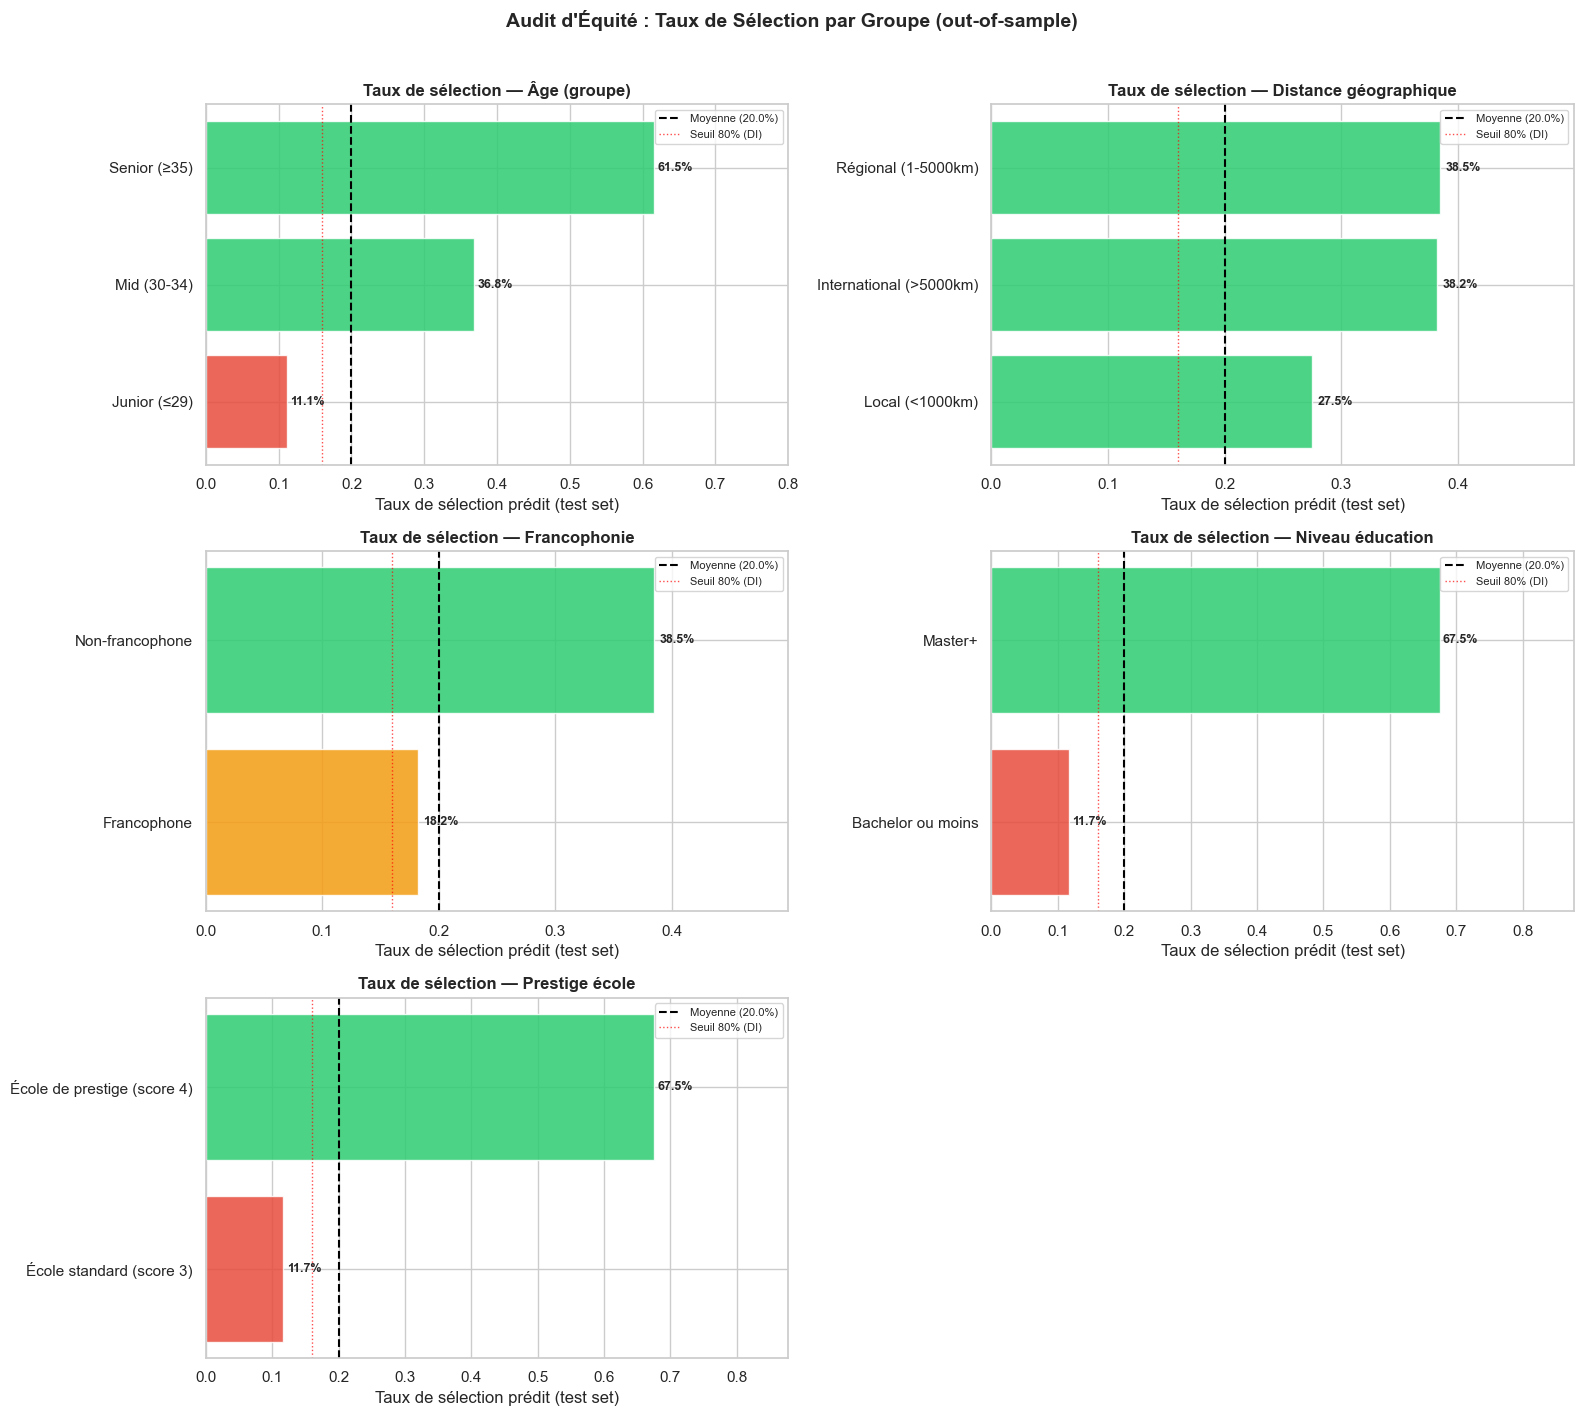

In [8]:
# ── Graphique 1 : Taux de sélection par groupe (tous attributs, test set) ───
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

global_rate = df_audit_test['passed_next_stage'].mean()

for idx, (label, col) in enumerate(sensitive_attrs.items()):
    ax = axes[idx]
    metrics = all_metrics[label]
    sr = metrics['selection_rate'].sort_values()

    colors = ['#e74c3c' if v < global_rate * 0.8 else '#f39c12' if v < global_rate else '#2ecc71'
              for v in sr.values]

    bars = ax.barh(sr.index.astype(str), sr.values, color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(global_rate, color='black', linestyle='--', lw=1.5, label=f'Moyenne ({global_rate:.1%})')
    ax.axvline(global_rate * 0.8, color='red', linestyle=':', lw=1, alpha=0.7, label='Seuil 80% (DI)')

    for bar, val in zip(bars, sr.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.1%}', va='center', fontsize=9, fontweight='bold')

    ax.set_xlim(0, max(sr.values) * 1.3 if max(sr.values) > 0 else 0.5)
    ax.set_title(f'Taux de sélection — {label}', fontweight='bold')
    ax.set_xlabel('Taux de sélection prédit (test set)')
    ax.legend(fontsize=8)

# La 6e case n'est plus utilisée (target_role retiré des sensible attrs)
if len(axes) > len(sensitive_attrs):
    for k in range(len(sensitive_attrs), len(axes)):
        axes[k].axis('off')

plt.suptitle('Audit d\'Équité : Taux de Sélection par Groupe (out-of-sample)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


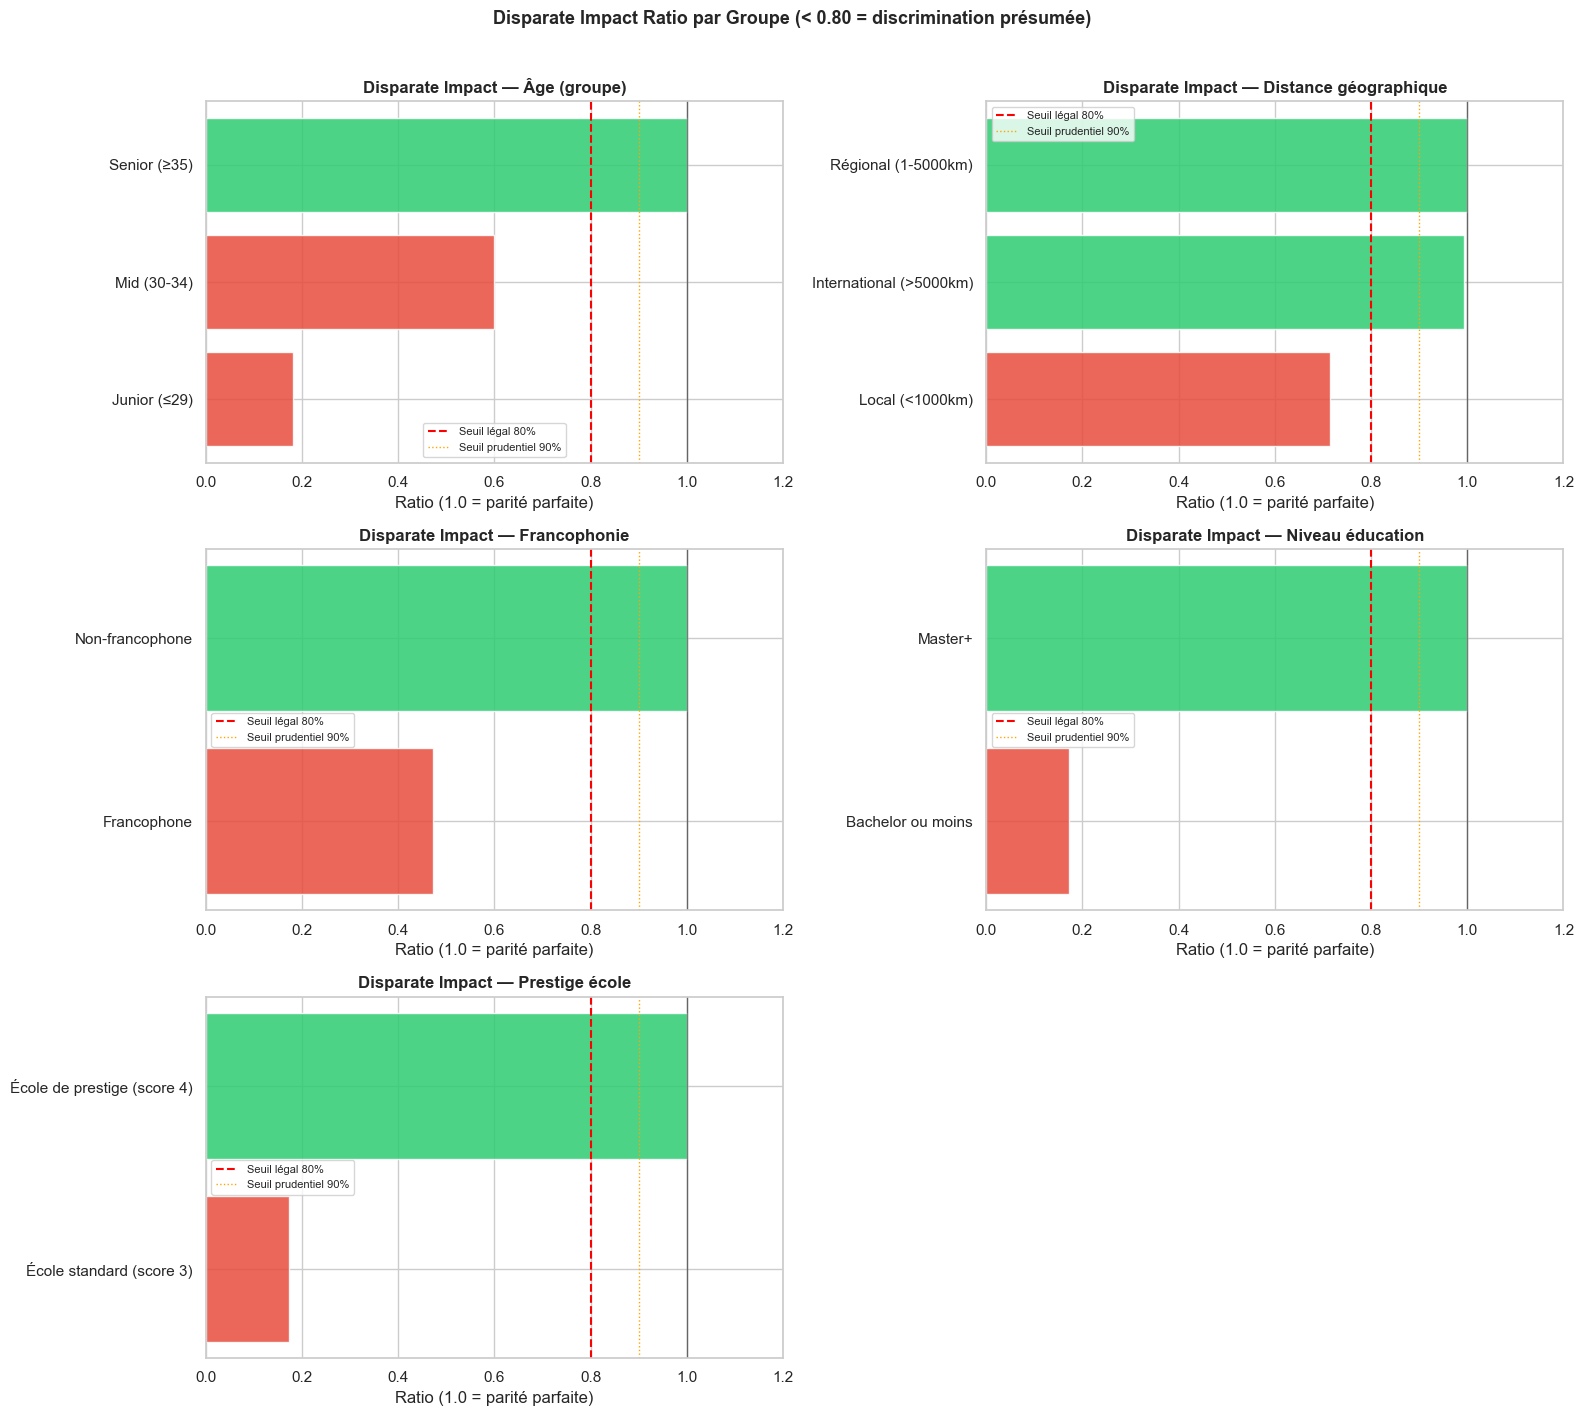

In [9]:
# ── Graphique 2 : Disparate Impact Ratio (test set) ─────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (label, col) in enumerate(sensitive_attrs.items()):
    ax = axes[idx]
    metrics = all_metrics[label]
    di = metrics['disparate_impact'].sort_values()

    colors = ['#e74c3c' if v < 0.80 else '#f39c12' if v < 0.90 else '#2ecc71' for v in di.values]
    ax.barh(di.index.astype(str), di.values, color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(1.0, color='black', linestyle='-', lw=1, alpha=0.5)
    ax.axvline(0.80, color='red', linestyle='--', lw=1.5, label='Seuil légal 80%')
    ax.axvline(0.90, color='orange', linestyle=':', lw=1, label='Seuil prudentiel 90%')

    ax.set_xlim(0, 1.2)
    ax.set_title(f'Disparate Impact — {label}', fontweight='bold')
    ax.set_xlabel('Ratio (1.0 = parité parfaite)')
    ax.legend(fontsize=8)

if len(axes) > len(sensitive_attrs):
    for k in range(len(sensitive_attrs), len(axes)):
        axes[k].axis('off')

plt.suptitle('Disparate Impact Ratio par Groupe (< 0.80 = discrimination présumée)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


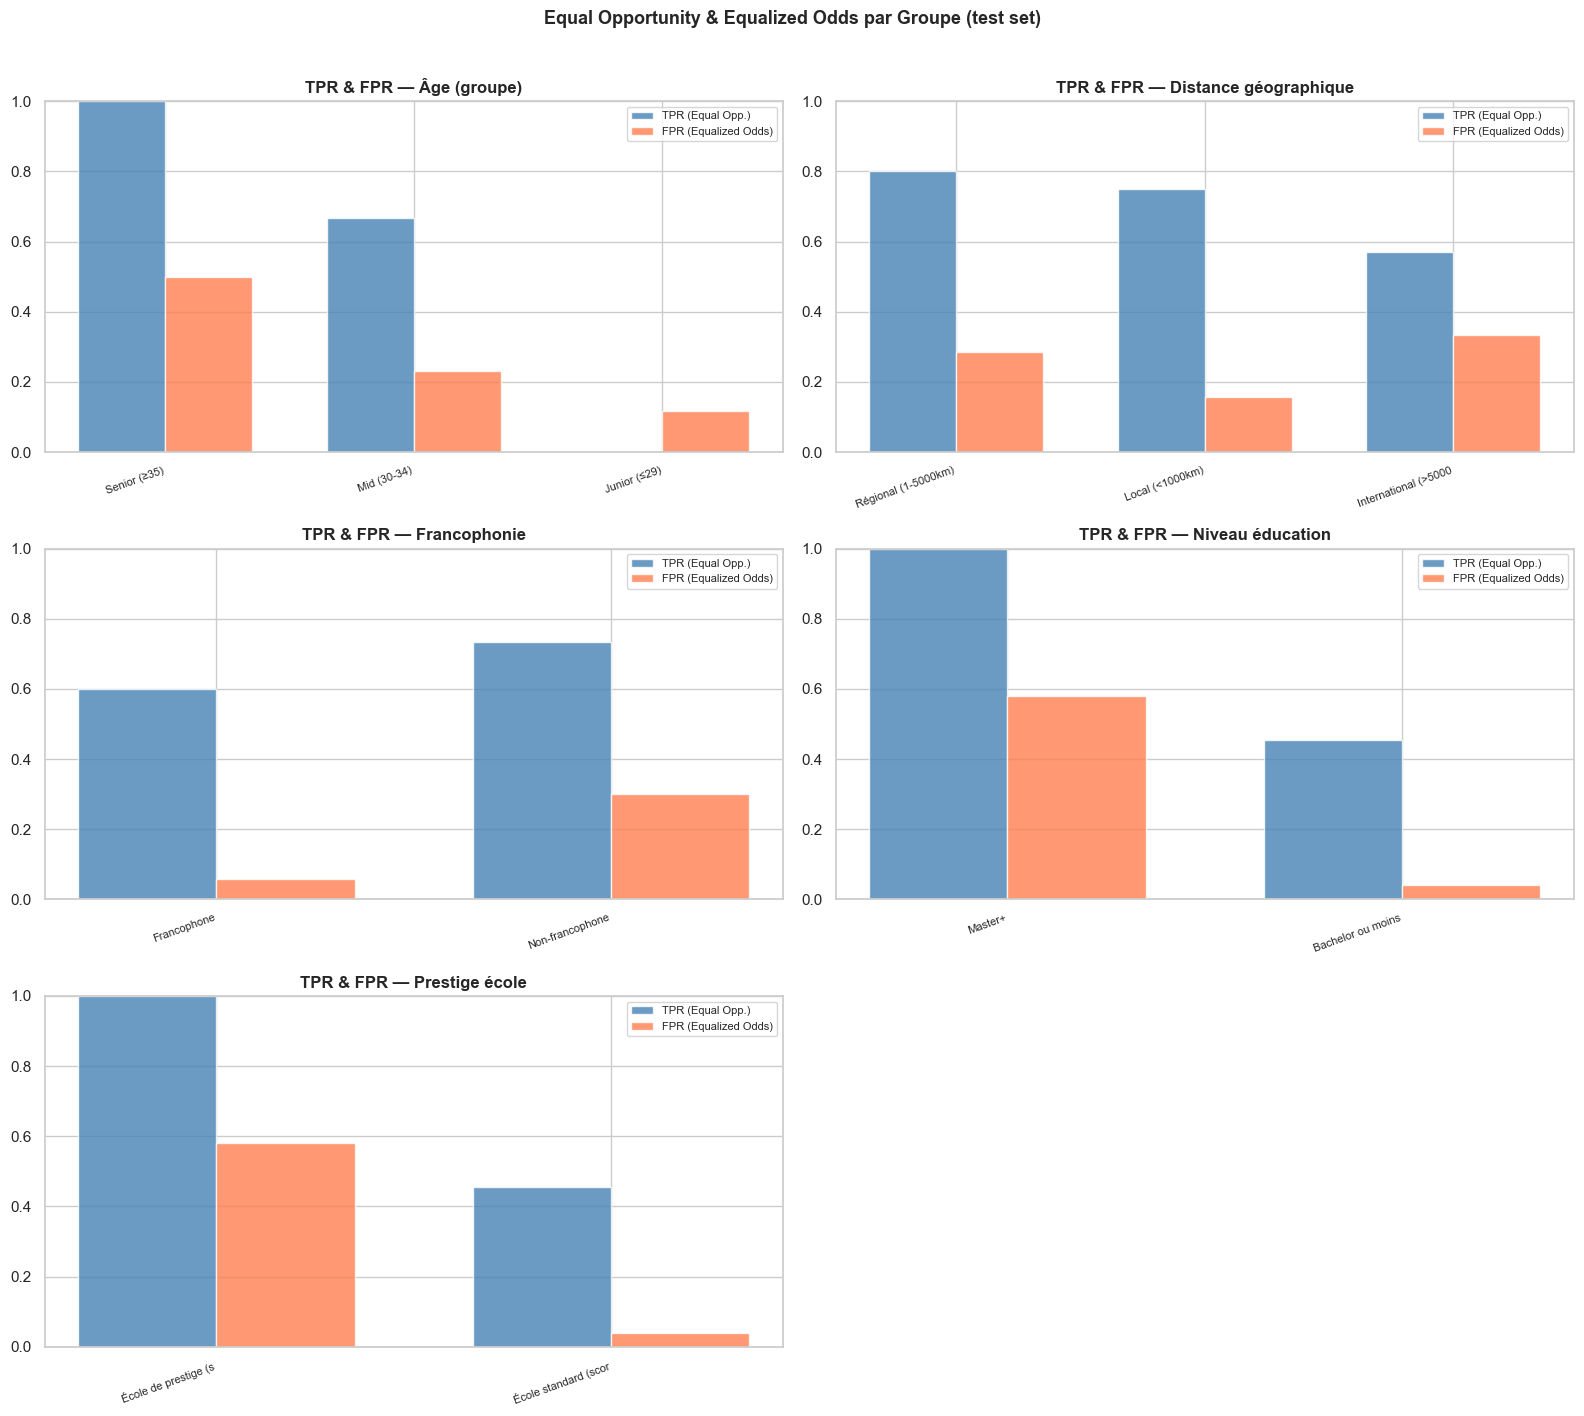

In [10]:
# ── Graphique 3 : Equal Opportunity (TPR) & Equalized Odds (FPR) ────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (label, col) in enumerate(sensitive_attrs.items()):
    ax = axes[idx]
    metrics = all_metrics[label].dropna(subset=['tpr', 'fpr'])

    x = np.arange(len(metrics))
    w = 0.35
    ax.bar(x - w / 2, metrics['tpr'], w, label='TPR (Equal Opp.)', color='steelblue', alpha=0.8)
    ax.bar(x + w / 2, metrics['fpr'], w, label='FPR (Equalized Odds)', color='coral', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([str(g)[:20] for g in metrics.index], rotation=20, ha='right', fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'TPR & FPR — {label}', fontweight='bold')
    ax.legend(fontsize=8)

if len(axes) > len(sensitive_attrs):
    for k in range(len(sensitive_attrs), len(axes)):
        axes[k].axis('off')

plt.suptitle('Equal Opportunity & Equalized Odds par Groupe (test set)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 7. Analyse Détaillée par Attribut Sensible

=== ANALYSE : ÂGE (test set, out-of-sample) ===



,n,n_pos_true,selection_rate,tpr,fpr,ppv,disparate_impact,dp_diff
group,,,,,,,,
Senior (≥35),26,6,0.615,1.000,0.500,0.375,1.000,0.000
Mid (30-34),38,12,0.368,0.667,0.231,0.571,0.599,-0.247
Junior (≤29),36,2,0.111,0.000,0.118,0.000,0.181,-0.504



Corrélation âge vs probabilité de sélection (full dataset) :
  Pearson r = 0.543  (corrélation positive)


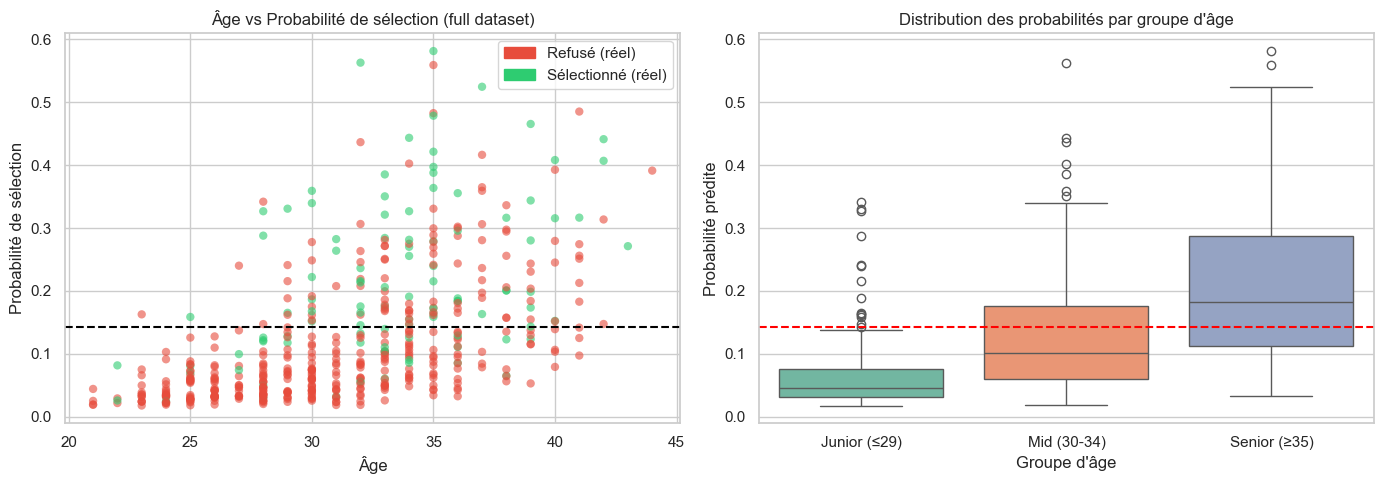

In [11]:
# ── 7.1 : Âge — analyse approfondie (test set) ──────────────────────────────
print('=== ANALYSE : ÂGE (test set, out-of-sample) ===')
print()
metrics_age = all_metrics['Âge (groupe)']
display(metrics_age[['n', 'n_pos_true', 'selection_rate', 'tpr', 'fpr', 'ppv', 'disparate_impact', 'dp_diff']].round(3))

print()
# Corrélation calculée sur tout le dataset (la corrélation est une mesure descriptive,
# pas une métrique de performance, donc le full dataset est adapté ici)
print('Corrélation âge vs probabilité de sélection (full dataset) :')
corr = df_audit[['age', 'proba']].corr().iloc[0, 1]
print(f'  Pearson r = {corr:.3f}  ({"corrélation positive" if corr > 0 else "corrélation négative"})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_audit['age'], df_audit['proba'],
                c=df_audit['passed_next_stage'].map({0: '#e74c3c', 1: '#2ecc71'}),
                alpha=0.6, edgecolors='none')
axes[0].axhline(best_threshold, color='black', linestyle='--', lw=1.5, label=f'Seuil {best_threshold:.2f}')
axes[0].set_xlabel('Âge')
axes[0].set_ylabel('Probabilité de sélection')
axes[0].set_title('Âge vs Probabilité de sélection (full dataset)')
red_patch = mpatches.Patch(color='#e74c3c', label='Refusé (réel)')
green_patch = mpatches.Patch(color='#2ecc71', label='Sélectionné (réel)')
axes[0].legend(handles=[red_patch, green_patch])

sns.boxplot(data=df_audit, x='age_group', y='proba', ax=axes[1],
            palette='Set2', order=['Junior (≤29)', 'Mid (30-34)', 'Senior (≥35)'])
axes[1].axhline(best_threshold, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Distribution des probabilités par groupe d\'âge')
axes[1].set_xlabel('Groupe d\'âge')
axes[1].set_ylabel('Probabilité prédite')

plt.tight_layout()
plt.show()


In [12]:
# ── 7.2 : Distance géographique (test set) ──────────────────────────────────
print('=== ANALYSE : DISTANCE GÉOGRAPHIQUE (test set) ===')
display(all_metrics['Distance géographique'][['n', 'selection_rate', 'tpr', 'disparate_impact']].round(3))
print(
    f'   Corrélation distance vs proba (full): {df_audit[["distance_ville_haute_km", "proba"]].corr().iloc[0, 1]:.3f}')
print()
print('⚠ NOTE INTERPRÉTATIVE :')
print('   Le coefficient de distance_ville_haute_km est POSITIF dans le modèle.')
print('   Le modèle FAVORISE donc statistiquement les candidats lointains plutôt')
print('   que les locaux — ce n\'est pas une discrimination contre les internationaux.')
print('   La feature reste retirée du modèle FAIR par PRINCIPE (RGPD : minimisation des')
print('   données + risque de proxy d\'origine), pas pour corriger un biais avéré.')


=== ANALYSE : DISTANCE GÉOGRAPHIQUE (test set) ===


,n,selection_rate,tpr,disparate_impact
group,,,,
Régional (1-5000km),26,0.385,0.800,1.000
Local (<1000km),40,0.275,0.750,0.715
International (>5000km),34,0.382,0.571,0.994


   Corrélation distance vs proba (full): 0.071

⚠ NOTE INTERPRÉTATIVE :
   Le coefficient de distance_ville_haute_km est POSITIF dans le modèle.
   Le modèle FAVORISE donc statistiquement les candidats lointains plutôt
   que les locaux — ce n'est pas une discrimination contre les internationaux.
   La feature reste retirée du modèle FAIR par PRINCIPE (RGPD : minimisation des
   données + risque de proxy d'origine), pas pour corriger un biais avéré.


=== ANALYSE OPÉRATIONNELLE : RÔLE VISÉ (test set) ===
NB : Cette analyse est descriptive — un écart de taux par rôle est attendu
     et ne constitue pas une discrimination au sens juridique.



,n,selection_rate,tpr,fpr,disparate_impact
group,,,,,
Product Analyst,6,0.667,1.000,0.600,1.000
ML Engineer,9,0.556,1.000,0.429,0.833
DevOps Engineer,13,0.462,1.000,0.364,0.692
Frontend Developer,7,0.429,0.500,0.333,0.643
Data Engineer,7,0.429,1.000,0.333,0.643
Backend Developer,15,0.400,1.000,0.308,0.600
Data Analyst,12,0.333,0.750,0.125,0.500
Data Scientist,10,0.200,0.333,0.143,0.300
Software Engineer,9,0.111,0.000,0.125,0.167


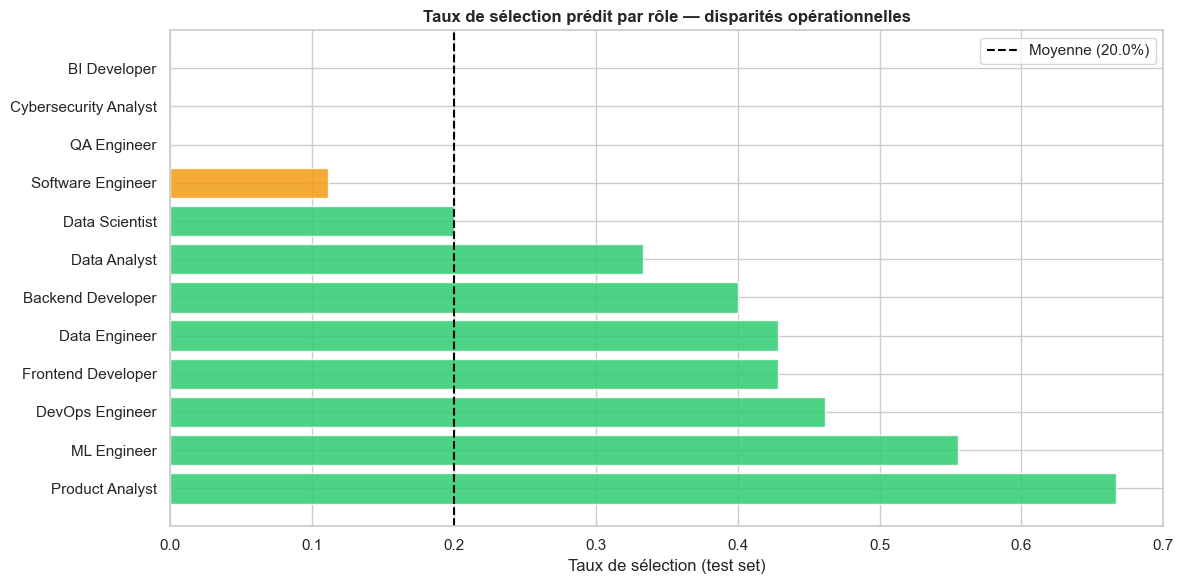

In [13]:
# ── 7.3 : Disparités inter-rôles (analyse opérationnelle, NON un audit d'équité) ──
# Le rôle visé n'est PAS un attribut protégé — différents postes ont légitimement
# des critères différents. Cette section sert uniquement à détecter d'éventuels
# rôles très sous-sélectionnés qui mériteraient un examen métier (pas légal).
print('=== ANALYSE OPÉRATIONNELLE : RÔLE VISÉ (test set) ===')
print('NB : Cette analyse est descriptive — un écart de taux par rôle est attendu')
print('     et ne constitue pas une discrimination au sens juridique.')
print()
metrics_role, _, _ = compute_fairness_metrics(df_audit_test, 'target_role')
metrics_role = metrics_role.sort_values('selection_rate', ascending=False)
display(metrics_role[['n', 'selection_rate', 'tpr', 'fpr', 'disparate_impact']].round(3))

fig, ax = plt.subplots(figsize=(12, 6))
sr = metrics_role['selection_rate']
mean_rate = df_audit_test['passed_next_stage'].mean()
colors = ['#e74c3c' if v < mean_rate * 0.5 else '#f39c12' if v < mean_rate else '#2ecc71'
          for v in sr.values]
ax.barh(sr.index.astype(str), sr.values, color=colors, alpha=0.85)
ax.axvline(mean_rate, color='black', linestyle='--', lw=1.5, label=f'Moyenne ({mean_rate:.1%})')
ax.set_title('Taux de sélection prédit par rôle — disparités opérationnelles', fontweight='bold')
ax.set_xlabel('Taux de sélection (test set)')
ax.legend()
plt.tight_layout()
plt.show()


## 7.4 Analyse Intersectionnelle

La conférence a insisté sur le fait que les discriminations sont souvent *croisées* : l'IA peut traiter défavorablement une combinaison de caractéristiques alors que chaque attribut pris seul ne déclenche pas d'alerte.

Nous testons ici deux croisements pertinents : `age_group × fr_speaker` et `age_group × geo_group`.

**Comment lire les heatmaps qui suivent :**

- Les valeurs sont des **taux de sélection prédits** (`pred`), pas des qualifications réelles. Un taux faible ne prouve pas une discrimination en soi : il peut refléter une base rate de qualification réellement plus faible dans cette cellule.
- L'alerte intersectionnelle se déclenche surtout quand l'écart d'une cellule est **plus marqué que ce qu'on attendrait en additionnant les effets marginaux** des deux attributs (signature d'une interaction non-additive).
- Les cellules avec effectif < 5 sont indicatives, pas conclusives.
- Une vraie analyse causale demanderait de comparer cellule par cellule au taux de qualification réel (`passed_next_stage`) — limité ici par la taille du test set (100 candidats).


=== CROISEMENT 1 : Âge × Francophonie (test set) ===
Taux de sélection prédit :


fr_speaker,Francophone,Non-francophone
age_group,,
Junior (≤29),0.000,0.143
Mid (30-34),0.125,0.433
Senior (≥35),0.500,0.650


Effectifs par cellule :


fr_speaker,Francophone,Non-francophone
age_group,,
Junior (≤29),8,28
Mid (30-34),8,30
Senior (≥35),6,20



=== CROISEMENT 2 : Âge × Géographie (test set) ===
Taux de sélection prédit :


geo_group,Local (<1000km),Régional (1-5000km),International (>5000km)
age_group,,,
Junior (≤29),0.062,0.000,0.231
Mid (30-34),0.375,0.273,0.455
Senior (≥35),0.500,0.875,0.500


Effectifs par cellule :


geo_group,Local (<1000km),Régional (1-5000km),International (>5000km)
age_group,,,
Junior (≤29),16,7,13
Mid (30-34),16,11,11
Senior (≥35),8,8,10


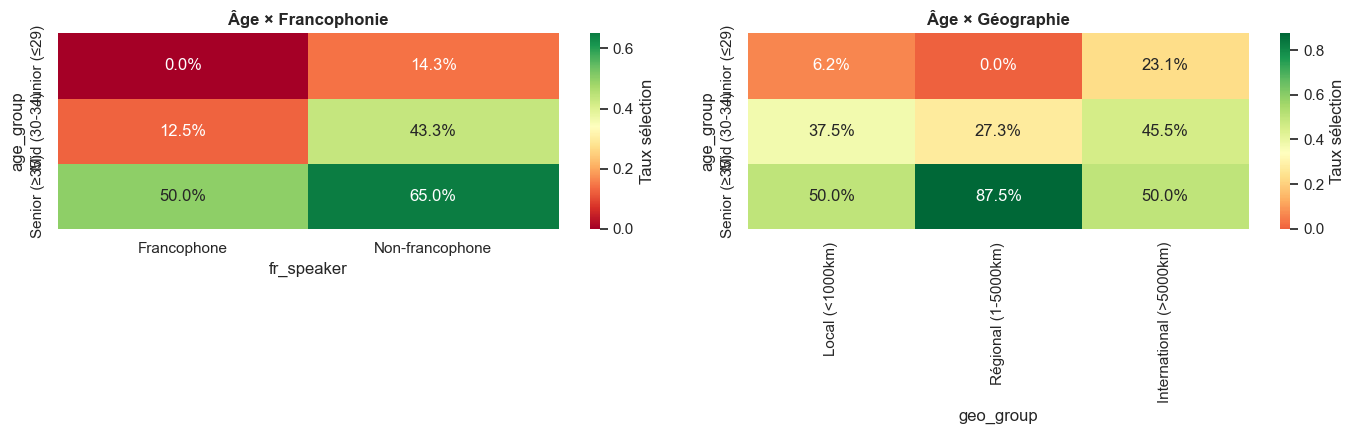


Interprétation :
  • Les cellules avec effectif < 5 doivent être interprétées avec prudence.
  • Un écart inter-cellules > l'écart marginal des deux attributs pris seuls
    suggère une discrimination intersectionnelle non détectée par l'analyse
    attribut par attribut.


In [14]:
# ── Analyse jointe sur le test set ──────────────────────────────────────────
def cross_table(df, row_col, col_col, value_col='pred'):
    pivot = df.groupby([row_col, col_col], observed=True)[value_col].agg(['mean', 'count']).reset_index()
    sr_pivot = pivot.pivot(index=row_col, columns=col_col, values='mean')
    n_pivot = pivot.pivot(index=row_col, columns=col_col, values='count')
    return sr_pivot, n_pivot


print('=== CROISEMENT 1 : Âge × Francophonie (test set) ===')
sr_ax_fr, n_ax_fr = cross_table(df_audit_test, 'age_group', 'fr_speaker')
print('Taux de sélection prédit :')
display(sr_ax_fr.round(3))
print('Effectifs par cellule :')
display(n_ax_fr.fillna(0).astype(int))

print()
print('=== CROISEMENT 2 : Âge × Géographie (test set) ===')
sr_ax_geo, n_ax_geo = cross_table(df_audit_test, 'age_group', 'geo_group')
print('Taux de sélection prédit :')
display(sr_ax_geo.round(3))
print('Effectifs par cellule :')
display(n_ax_geo.fillna(0).astype(int))

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.heatmap(sr_ax_fr, annot=True, fmt='.1%', cmap='RdYlGn', center=df_audit_test['pred'].mean(),
            ax=axes[0], cbar_kws={'label': 'Taux sélection'})
axes[0].set_title('Âge × Francophonie', fontweight='bold')
sns.heatmap(sr_ax_geo, annot=True, fmt='.1%', cmap='RdYlGn', center=df_audit_test['pred'].mean(),
            ax=axes[1], cbar_kws={'label': 'Taux sélection'})
axes[1].set_title('Âge × Géographie', fontweight='bold')
plt.tight_layout()
plt.show()

print()
print('Interprétation :')
print('  • Les cellules avec effectif < 5 doivent être interprétées avec prudence.')
print('  • Un écart inter-cellules > l\'écart marginal des deux attributs pris seuls')
print('    suggère une discrimination intersectionnelle non détectée par l\'analyse')
print('    attribut par attribut.')


## 8. Explicabilité du Modèle — Coefficients L1 & Impact des Features Sensibles

L'explicabilité est une exigence de l'AI Act (Art. 13 : transparence) et du RGPD Art. 22.

In [15]:
# ── Extraction des coefficients du modèle ────────────────────────────────────
preprocessor = lr_pipeline.named_steps['preprocessor']
classifier = lr_pipeline.named_steps['classifier']

NUMERIC_FEATURES = [
    'age', 'distance_ville_haute_km', 'total_experience_years',
    'nb_gaps', 'avg_gap_duration', 'gap_ratio', 'education_score',
    'skills_count', 'certif_count', 'has_certif',
    'lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum',
]
CATEGORICAL_FEATURES = ['target_role', 'education_degree', 'education_field']

ohe_names = (
    preprocessor.named_transformers_['cat']
    .named_steps['ohe']
    .get_feature_names_out(CATEGORICAL_FEATURES)
    .tolist()
)

skills_names = [
    f"skill_{w}" for w in
    preprocessor.named_transformers_['skills'].get_feature_names_out()
]
certif_names = [
    f"certif_{w}" for w in
    preprocessor.named_transformers_['certif'].get_feature_names_out()
]

feature_names = NUMERIC_FEATURES + ohe_names + skills_names + certif_names
coefs = classifier.coef_[0]

coef_df = (
    pd.DataFrame({'feature': feature_names, 'coef': coefs, 'abs_coef': np.abs(coefs)})
    .sort_values('abs_coef', ascending=False)
)

active_features = coef_df[coef_df['abs_coef'] > 0]
print(f'Features actives (L1) : {len(active_features)} / {len(coef_df)}')
print()
display(active_features.head(20))

Features actives (L1) : 9 / 128



,feature,coef,abs_coef
2,total_experience_years,0.709856,0.709856
6,education_score,0.423847,0.423847
8,certif_count,0.212442,0.212442
12,lang_de,0.102665,0.102665
13,lang_es,0.085400,0.085400
15,lang_other_score_sum,0.079456,0.079456
5,gap_ratio,-0.070721,0.070721
1,distance_ville_haute_km,0.039604,0.039604
14,lang_it,-0.007302,0.007302


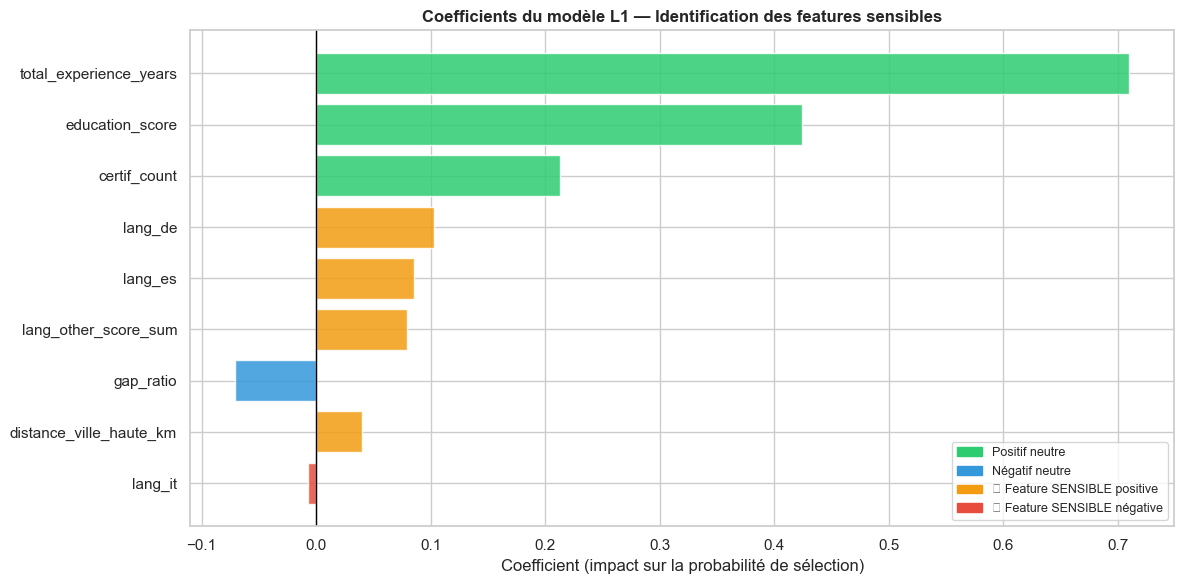

In [16]:
# ── Visualisation des coefficients avec highlighting des features sensibles ──
SENSITIVE_FEATURES = ['age', 'distance_ville_haute_km', 'lang_fr', 'lang_en', 'lang_de',
                      'lang_es', 'lang_it', 'lang_other_score_sum']

fig, ax = plt.subplots(figsize=(12, max(6, len(active_features) * 0.4)))

colors_coef = []
for _, row in active_features.iterrows():
    feat = row['feature']
    is_sensitive = any(s in feat for s in SENSITIVE_FEATURES)
    if is_sensitive:
        colors_coef.append('#e74c3c' if row['coef'] < 0 else '#f39c12')
    else:
        colors_coef.append('#2ecc71' if row['coef'] > 0 else '#3498db')

bars = ax.barh(
    active_features['feature'].values[::-1],
    active_features['coef'].values[::-1],
    color=colors_coef[::-1],
    alpha=0.85, edgecolor='white'
)
ax.axvline(0, color='black', lw=1)

legend_patches = [
    mpatches.Patch(color='#2ecc71', label='Positif neutre'),
    mpatches.Patch(color='#3498db', label='Négatif neutre'),
    mpatches.Patch(color='#f39c12', label='⚠ Feature SENSIBLE positive'),
    mpatches.Patch(color='#e74c3c', label='⚠ Feature SENSIBLE négative'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
ax.set_title('Coefficients du modèle L1 — Identification des features sensibles', fontweight='bold')
ax.set_xlabel('Coefficient (impact sur la probabilité de sélection)')

plt.tight_layout()
plt.show()

In [17]:
# ── Analyse de la contribution individuelle par feature sensible ─────────────
print('=== IMPACT DES FEATURES SENSIBLES DANS LE MODÈLE ===')
print()

sensitive_active = active_features[active_features['feature'].isin(SENSITIVE_FEATURES)]

if len(sensitive_active) > 0:
    for _, row in sensitive_active.iterrows():
        direction = 'FAVORISE' if row['coef'] > 0 else 'PÉNALISE'
        print(f"  • {row['feature']:<35} coef={row['coef']:+.4f}  → {direction} la sélection")
    print()
    print('⚠ ALERTE : Les features suivantes ont une influence directe dans le modèle')
    print('   et peuvent introduire une discrimination indirecte ou directe :')
    for feat in sensitive_active['feature'].tolist():
        print(f'   - {feat}')
else:
    print('Aucune feature sensible n\'a de coefficient non-nul (L1 les a éliminées).')

=== IMPACT DES FEATURES SENSIBLES DANS LE MODÈLE ===

  • lang_de                             coef=+0.1027  → FAVORISE la sélection
  • lang_es                             coef=+0.0854  → FAVORISE la sélection
  • lang_other_score_sum                coef=+0.0795  → FAVORISE la sélection
  • distance_ville_haute_km             coef=+0.0396  → FAVORISE la sélection
  • lang_it                             coef=-0.0073  → PÉNALISE la sélection

⚠ ALERTE : Les features suivantes ont une influence directe dans le modèle
   et peuvent introduire une discrimination indirecte ou directe :
   - lang_de
   - lang_es
   - lang_other_score_sum
   - distance_ville_haute_km
   - lang_it


## 9. Stratégies Correctives

### Techniques implémentées

| Stratégie | Type | Principe |
|---|---|---|
| **Suppression features sensibles + proxies** | Pre-processing | Retirer `age`, `distance_ville_haute_km` ET les langues identifiées comme proxies de nationalité (`lang_de`, `lang_es`, `lang_it`, `lang_other_score_sum`). Cohérence diagnostic ↔ traitement. |
| **Class weight (`balanced`)** | In-processing | Compense le déséquilibre 80/20 entre classes — ce *n'est pas* une technique de fairness, juste une stabilisation prédictive. |
| **Calibration du seuil par groupe** | Post-processing | Ajuste le seuil par groupe d'âge sur le **set de validation**, pour rapprocher les TPR. *Présentée à titre exploratoire — voir avertissement légal après §9.2.* |

### Lignes directrices méthodologiques appliquées

- **Pas de data leakage** : tuning du seuil F-beta et calibration de groupe se font sur un **set de validation séparé** ; le test set est réservé à l'évaluation finale.
- **Audit out-of-sample** : toutes les métriques d'équité (sections 5–7, 10) sont calculées sur le test set uniquement (100 candidats sur 500).
- **`target_role` exclu des sensible attrs** : le rôle visé n'est pas un attribut protégé, il est analysé séparément (§7.3).

> **À noter sur la calibration §9.2 :** la calibration ne donne pas une parité parfaite des TPR. Sur la validation, les TPR atteints sont d'environ 50–65% selon le groupe — l'algorithme se rapproche du TPR cible sans nécessairement l'atteindre exactement. Pire : pour égaliser le TPR du groupe Junior, le seuil tombe très bas et le **taux de sélection global de ce groupe explose** (~93% sur le full dataset), ce qui illustre concrètement pourquoi cette stratégie n'est pas déployable.


In [18]:
# ── Stratégie 1 : Modèle sans features sensibles (directes ET proxies) ─────
# Le diagnostic des sections 5–8 a montré que :
#   • age + distance sont des features sensibles directes
#   • lang_de, lang_es, lang_other_score_sum ont des coefficients actifs et
#     constituent des proxies de nationalité (Section 13).
# Nous retirons donc TOUTES ces features pour cohérence diagnostic ↔ traitement.
# lang_fr et lang_en sont CONSERVÉES car elles peuvent être réellement
# fonctionnelles dans un contexte belgo-européen (justifiable au sens RGPD).
print('=== STRATÉGIE 1 : Modèle équitable ===')
print('Suppression : age, distance_ville_haute_km, lang_de, lang_es, lang_it, lang_other_score_sum')
print()

NUMERIC_FEATURES_FAIR = [
    # 'age',  ← SUPPRIMÉ (sensible direct)
    # 'distance_ville_haute_km',  ← SUPPRIMÉ (proxy géographique)
    'total_experience_years',
    'nb_gaps', 'avg_gap_duration', 'gap_ratio', 'education_score',
    'skills_count', 'certif_count', 'has_certif',
    'lang_fr', 'lang_en',
    # 'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum',  ← SUPPRIMÉS (proxies nationalité)
]

preprocessor_fair = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), NUMERIC_FEATURES_FAIR),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CATEGORICAL_FEATURES),
    ('skills', TfidfVectorizer(max_features=50, token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=1), 'skills'),
    ('certif', TfidfVectorizer(max_features=30, token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=2), 'certifications'),
], remainder='drop')

# Note : on conserve l'équilibrage de classes du modèle d'origine pour la comparabilité.
# Le `class_weight` traite le déséquilibre 80/20 — ce N'EST PAS une technique
# de fairness en soi, juste une stabilisation du modèle.
lr_fair = ImbPipeline([
    ('preprocessor', preprocessor_fair),
    ('classifier', LogisticRegressionCV(
        Cs=10, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        penalty='l1', solver='liblinear', scoring='average_precision',
        class_weight='balanced',  # plus standard et reproductible
        max_iter=1000, random_state=RANDOM_STATE,
    )),
])

# ── Split train / VAL / test (60 / 20 / 20) pour éviter le data leakage ─────
TARGET = 'passed_next_stage'
df_fe = df_audit.copy()
X_fe = df_fe.drop(columns=['cv_id', TARGET, 'proba', 'pred', 'split',
                           'age_group', 'geo_group', 'fr_speaker', 'edu_level', 'edu_score_group'])
y_fe = df_fe[TARGET]

# X_all_fair = vue complète pour l'inférence et le SHAP
X_all_fair = X_fe.copy()

# Premier split : 80% (train+val) / 20% (test)  — ALIGNÉ sur le split original (random_state=42)
X_trainval, X_te_f, y_trainval, y_te_f = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=RANDOM_STATE, stratify=y_fe)

# Deuxième split : sur les 80% restants → 75% train / 25% val (≈ 60/20 du total)
X_tr_f, X_val_f, y_tr_f, y_val_f = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y_trainval)

print(f'Split : train={len(X_tr_f)}  |  val={len(X_val_f)}  |  test={len(X_te_f)}')

lr_fair.fit(X_tr_f, y_tr_f)

# ── Tuning du seuil F-beta SUR LA VALIDATION (pas le test) ──────────────────
y_proba_val = lr_fair.predict_proba(X_val_f)[:, 1]
precs_v, recs_v, thrs_v = precision_recall_curve(y_val_f, y_proba_val)
beta = 0.5
fbeta_v = (1 + beta ** 2) * (precs_v * recs_v) / (beta ** 2 * precs_v + recs_v + 1e-9)
threshold_fair = thrs_v[np.argmax(fbeta_v[:-1])]

# Évaluation finale sur le TEST set (jamais touché)
y_proba_fair = lr_fair.predict_proba(X_te_f)[:, 1]
y_pred_fair_te = (y_proba_fair >= threshold_fair).astype(int)

print(f'Seuil optimal (tuné sur VALIDATION) : {threshold_fair:.4f}')
print()
print('Performances sur le jeu de test (jamais utilisé pour le tuning) :')
print(classification_report(y_te_f, y_pred_fair_te, target_names=['Refusé', 'Sélectionné']))
print(f'ROC-AUC test : {roc_auc_score(y_te_f, y_proba_fair):.3f}')


=== STRATÉGIE 1 : Modèle équitable ===
Suppression : age, distance_ville_haute_km, lang_de, lang_es, lang_it, lang_other_score_sum

Split : train=300  |  val=100  |  test=100


Seuil optimal (tuné sur VALIDATION) : 0.6352

Performances sur le jeu de test (jamais utilisé pour le tuning) :
              precision    recall  f1-score   support

      Refusé       0.88      0.80      0.84        80
 Sélectionné       0.41      0.55      0.47        20

    accuracy                           0.75       100
   macro avg       0.64      0.68      0.65       100
weighted avg       0.78      0.75      0.76       100

ROC-AUC test : 0.687


In [19]:
# ── Stratégie 2 : Calibration du seuil par groupe (post-processing) ─────────
# IMPORTANT : la calibration est faite sur le set de VALIDATION,
# le test set reste vierge pour l'évaluation finale.
print('=== STRATÉGIE 2 : Calibration de seuil par groupe d\'âge (Equal Opportunity) ===')
print('NB : calibration sur le SET DE VALIDATION, évaluation sur le test.')
print()

# Recalculer les probas du fair model sur la validation
df_val_calib = df_audit.iloc[X_val_f.index].copy()
df_val_calib['proba_fair'] = y_proba_val  # déjà calculé en cellule précédente

# TPR cible = TPR global atteint sur la validation au seuil_fair
y_pred_val_global = (df_val_calib['proba_fair'] >= threshold_fair).astype(int)
mask_pos = df_val_calib[TARGET] == 1
target_tpr = float(y_pred_val_global[mask_pos].mean()) if mask_pos.sum() > 0 else 0.65
print(f'TPR cible (= TPR global atteint sur validation) : {target_tpr:.1%}')
print()

group_thresholds = {}

for group in df_val_calib['age_group'].dropna().unique():
    mask = df_val_calib['age_group'] == group
    sub = df_val_calib[mask]

    y_true_g = sub[TARGET]
    y_proba_g = sub['proba_fair']

    if y_true_g.sum() == 0:
        group_thresholds[group] = threshold_fair
        continue

    precs_g, recs_g, thrs_g = precision_recall_curve(y_true_g, y_proba_g)

    best_thr = threshold_fair
    best_gap = float('inf')
    for thr, tpr_val in zip(thrs_g, recs_g[:-1]):
        gap = abs(tpr_val - target_tpr)
        if gap < best_gap:
            best_gap = gap
            best_thr = thr

    group_thresholds[group] = float(best_thr)
    actual_tpr = (y_proba_g >= best_thr).astype(int)[y_true_g == 1].mean()
    print(f'  {str(group):<20}  seuil={best_thr:.3f}  TPR_val={actual_tpr:.1%}')

print()
print('Seuils calibrés (sur validation) :', {str(k): round(v, 3) for k, v in group_thresholds.items()})

# ── Application au TEST set + reporting global ──────────────────────────────
df_audit['proba_fair'] = lr_fair.predict_proba(X_all_fair)[:, 1]


def apply_group_threshold(row, group_col, thresholds, proba_col='proba_fair'):
    thr = thresholds.get(row[group_col], threshold_fair)
    return int(row[proba_col] >= thr)


df_audit['pred_calibrated'] = df_audit.apply(
    apply_group_threshold, axis=1,
    group_col='age_group', thresholds=group_thresholds
)

print()
print('Taux de sélection après calibration (par groupe d\'âge, full dataset) :')
print(df_audit.groupby('age_group', observed=True)['pred_calibrated'].mean().round(3))


=== STRATÉGIE 2 : Calibration de seuil par groupe d'âge (Equal Opportunity) ===
NB : calibration sur le SET DE VALIDATION, évaluation sur le test.

TPR cible (= TPR global atteint sur validation) : 60.0%

  Junior (≤29)          seuil=0.053  TPR_val=50.0%
  Mid (30-34)           seuil=0.698  TPR_val=57.1%
  Senior (≥35)          seuil=0.617  TPR_val=63.6%

Seuils calibrés (sur validation) : {'Junior (≤29)': 0.053, 'Mid (30-34)': 0.698, 'Senior (≥35)': 0.617}

Taux de sélection après calibration (par groupe d'âge, full dataset) :
age_group
Junior (≤29)    0.928
Mid (30-34)     0.213
Senior (≥35)    0.496
Name: pred_calibrated, dtype: float64


> ⚠️ **AVERTISSEMENT LÉGAL ET ÉTHIQUE : LE PIÈGE DU "DEMOGRAPHIC NORMING"**
>
> Bien que la calibration de seuils par groupe (post-processing) soit une technique mathématiquement valide pour forcer l'égalité des chances (*Equal Opportunity*), son application en production dans un contexte de recrutement est **fortement déconseillée**.
>
> * **Discrimination directe :** Appliquer un seuil d'acceptation plus clément à un candidat en raison de son âge (ex: 0.50 pour un senior vs 0.60 pour un junior) constitue du *demographic norming*. Sous la loi belge du 10 mai 2007 et la Directive européenne 2000/78/CE, imposer des standards de réussite différents basés sur une caractéristique protégée est illégal.
> * **AI Act & RGPD :** Le cadre juridique européen privilégie la **Stratégie 1** (retirer la variable sensible et repondérer en amont). L'IA doit appliquer un standard d'évaluation unique lors de l'inférence. Les attributs sensibles ne doivent être utilisés que dans des environnements de test pour *détecter* les biais (Art. 10 AI Act), et non pour *dicter* des seuils différenciés.
>
> **Conclusion :** Cette Stratégie 2 est présentée ici à **titre purement pédagogique et exploratoire**. Elle illustre l'incompatibilité fréquente entre l'équité algorithmique stricte (forcer la parité statistique) et le droit anti-discrimination (qui exige l'égalité formelle de traitement). **Elle ne doit pas être déployée en production.**

## 8b. Explicabilité SHAP — Valeurs de Shapley

### Pourquoi SHAP plutôt que les seuls coefficients ?

Les coefficients L1 (Section 8) mesurent l'impact *marginal* d'une feature dans le modèle. Les **valeurs SHAP** (SHapley Additive exPlanations) mesurent l'impact *réel* de chaque feature sur une prédiction donnée, en tenant compte des interactions et de la distribution des données.

**Ancrage éthique :** La conférence a insisté sur le principe d'**Explicabilité** (Floridi, *AI4People*) et l'Art. 13 de l'AI Act (transparence). SHAP permet de répondre concrètement à la question : *"Pourquoi ce candidat a-t-il été refusé ?"*

| Méthode | Avantage | Limite |
|---|---|---|
| Coefficients L1 | Globaux, rapides | Ignorent la distribution des données |
| SHAP | Locaux (par individu) + globaux | Plus coûteux en calcul |


=== ANALYSE SHAP ===
SHAP calculé sur 300 candidats, 122 features

Graphique 1 : Importance globale des features (valeurs SHAP)


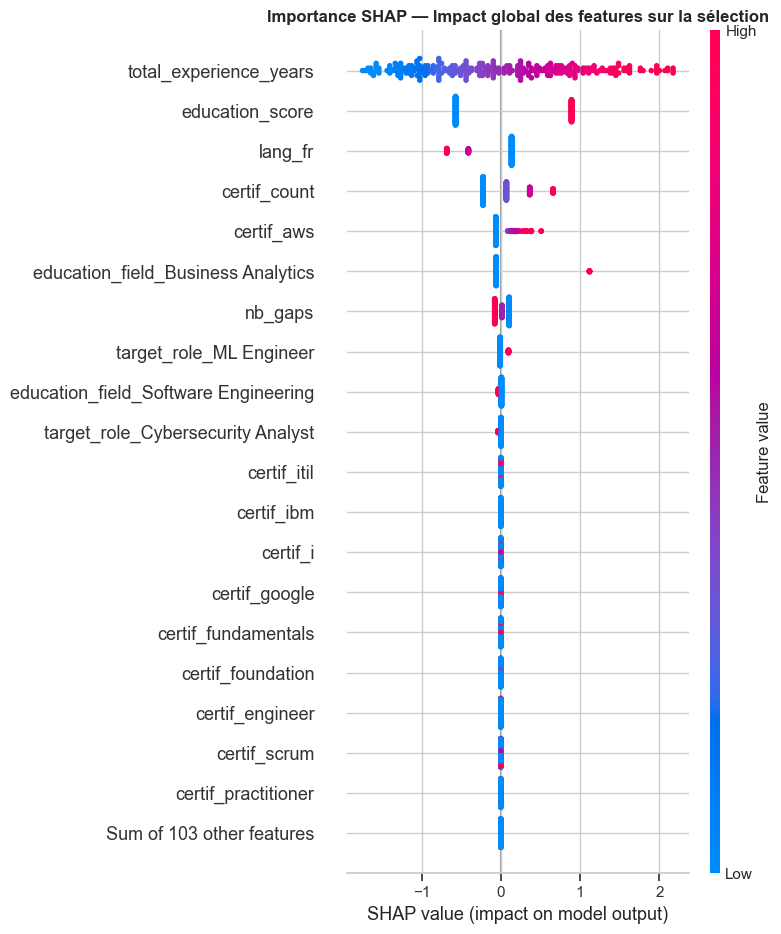

Graphique 2 : Importance moyenne absolue (SHAP bar plot)


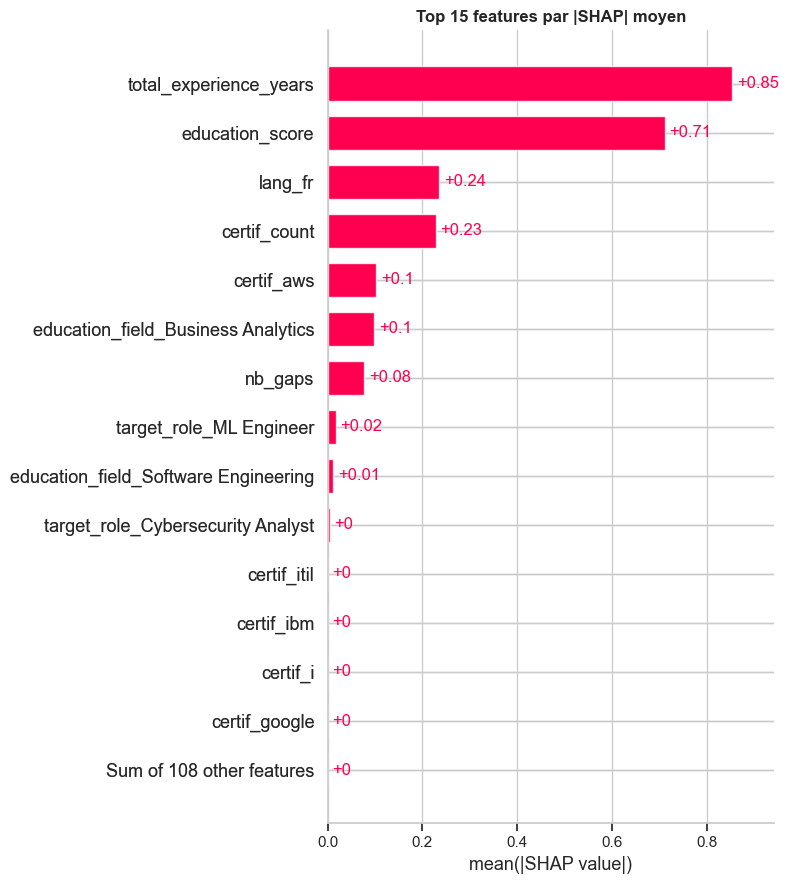


=== IMPACT SHAP DES FEATURES SENSIBLES ===
  lang_fr                              |SHAP| moyen = 0.2354  →  PÉNALISE (−)
  lang_en                              |SHAP| moyen = 0.0000  →  PÉNALISE (−)
  education_score                      |SHAP| moyen = 0.7113  →  FAVORISE (+)

Graphique 3 : Explication individuelle SHAP — Candidat index 0


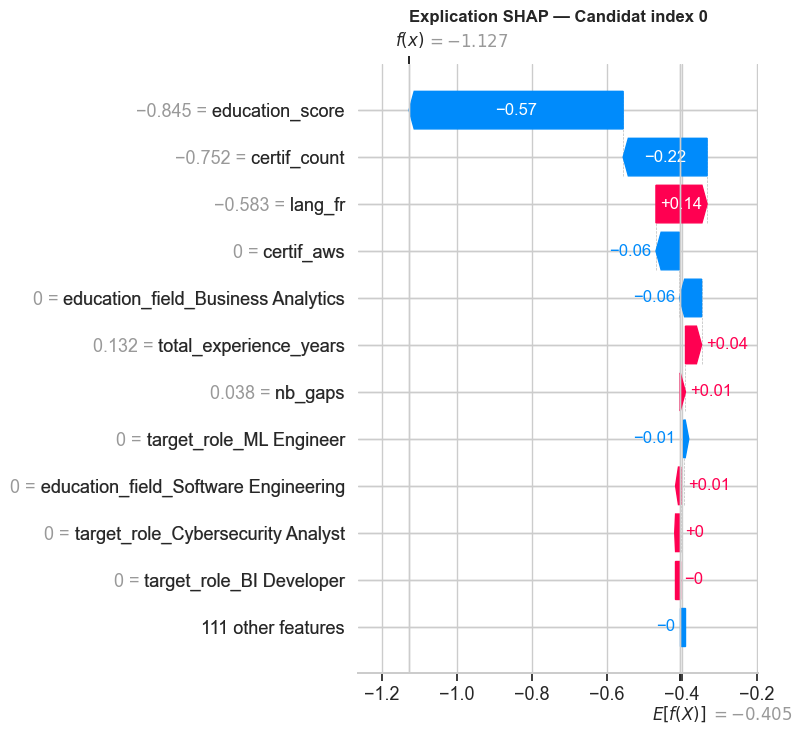


✅ SHAP — Interprétation éthique :
  • Les features avec un |SHAP| élevé sont les plus déterminantes.
  • Si lang_fr ou education_score dominent, cela confirme le risque de
    discrimination indirecte par proxy (conférence : intersectionnalité).
  • L'explication individuelle répond à l'Art. 14 AI Act : supervision humaine.


In [20]:
try:
    import shap

    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('⚠ shap non installé — exécutez : pip install shap')

if SHAP_AVAILABLE:
    print('=== ANALYSE SHAP ===')

    # Transformer les données avec le préprocesseur du modèle équitable
    prep_fair = lr_fair.named_steps['preprocessor']
    clf_fair = lr_fair.named_steps['classifier']

    # Reconstruire les noms de features
    ohe_names_fair = (
        prep_fair.named_transformers_['cat']
        .named_steps['ohe']
        .get_feature_names_out(CATEGORICAL_FEATURES)
    )
    skills_feat_fair = [f'skill_{w}' for w in prep_fair.named_transformers_['skills'].get_feature_names_out()]
    certif_feat_fair = [f'certif_{w}' for w in prep_fair.named_transformers_['certif'].get_feature_names_out()]
    all_feat_fair = list(NUMERIC_FEATURES_FAIR) + list(ohe_names_fair) + skills_feat_fair + certif_feat_fair

    # Transformer un échantillon (max 300 pour performance)
    sample_size = min(300, len(X_all_fair))
    X_sample = X_all_fair.sample(sample_size, random_state=RANDOM_STATE)
    X_sample_transformed = prep_fair.transform(X_sample)

    # LinearExplainer adapté à LogisticRegression
    explainer = shap.LinearExplainer(clf_fair, X_sample_transformed, feature_names=all_feat_fair)
    shap_values = explainer(X_sample_transformed)

    print(f'SHAP calculé sur {sample_size} candidats, {len(all_feat_fair)} features')
    print()

    # ── Graphique 1 : Importance globale (beeswarm) ──────────────────────────
    print('Graphique 1 : Importance globale des features (valeurs SHAP)')
    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plt.title('Importance SHAP — Impact global des features sur la sélection', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Graphique 2 : Bar plot (importance moyenne absolue) ──────────────────
    print('Graphique 2 : Importance moyenne absolue (SHAP bar plot)')
    shap.plots.bar(shap_values, max_display=15, show=False)
    plt.title('Top 15 features par |SHAP| moyen', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Analyse features sensibles via SHAP ──────────────────────────────────
    print()
    print('=== IMPACT SHAP DES FEATURES SENSIBLES ===')
    sensitive_feat_names = ['lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it',
                            'lang_other_score_sum', 'education_score']
    shap_df = pd.DataFrame(shap_values.values, columns=all_feat_fair)

    for feat in sensitive_feat_names:
        if feat in shap_df.columns:
            mean_abs = shap_df[feat].abs().mean()
            mean_val = shap_df[feat].mean()
            direction = 'FAVORISE (+)' if mean_val > 0 else 'PÉNALISE (−)'
            print(f'  {feat:<35}  |SHAP| moyen = {mean_abs:.4f}  →  {direction}')

    # ── Graphique 3 : Explication SHAP individuelle (candidat 0) ────────────
    print()
    print('Graphique 3 : Explication individuelle SHAP — Candidat index 0')
    shap.plots.waterfall(shap_values[0], max_display=12, show=False)
    plt.title(f'Explication SHAP — Candidat index 0', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print()
    print('✅ SHAP — Interprétation éthique :')
    print('  • Les features avec un |SHAP| élevé sont les plus déterminantes.')
    print('  • Si lang_fr ou education_score dominent, cela confirme le risque de')
    print('    discrimination indirecte par proxy (conférence : intersectionnalité).')
    print('  • L\'explication individuelle répond à l\'Art. 14 AI Act : supervision humaine.')


## 10. Comparaison Ancien vs Nouveau Modèle

In [21]:
# ── Recalcul des métriques d'équité pour le nouveau modèle (test set) ──────
df_audit['pred_fair'] = (df_audit['proba_fair'] >= threshold_fair).astype(int)
df_audit_test = df_audit[df_audit['split'] == 'test'].copy()

comparison_rows = []

for label, col in sensitive_attrs.items():
    m_old, dp_old, eod_old = compute_fairness_metrics(df_audit_test, col, y_pred_col='pred')
    di_old = m_old['disparate_impact'].min()

    m_new, dp_new, eod_new = compute_fairness_metrics(df_audit_test, col, y_pred_col='pred_fair')
    di_new = m_new['disparate_impact'].min()

    comparison_rows.append({
        'Attribut': label,
        'DP Gap — Ancien': round(dp_old, 4),
        'DP Gap — Nouveau': round(dp_new, 4),
        'Δ DP Gap': round(dp_old - dp_new, 4),
        'EOD — Ancien': round(eod_old, 4) if not np.isnan(eod_old) else np.nan,
        'EOD — Nouveau': round(eod_new, 4) if not np.isnan(eod_new) else np.nan,
        'DI min — Ancien': round(di_old, 4),
        'DI min — Nouveau': round(di_new, 4),
        'Amélioration DI': '✅' if di_new > di_old else '❌',
    })

comp_df = pd.DataFrame(comparison_rows).set_index('Attribut')
print('=== COMPARAISON ÉQUITÉ : ANCIEN vs NOUVEAU (test set out-of-sample) ===')
display(comp_df)


=== COMPARAISON ÉQUITÉ : ANCIEN vs NOUVEAU (test set out-of-sample) ===


,DP Gap — Ancien,DP Gap — Nouveau,Δ DP Gap,EOD — Ancien,EOD — Nouveau,DI min — Ancien,DI min — Nouveau,Amélioration DI
Attribut,,,,,,,,
Âge (groupe),0.5043,0.4444,0.0599,1.0000,0.6667,0.1805,0.1112,❌
Distance géographique,0.1096,0.1462,-0.0366,0.2286,0.1964,0.7150,0.5777,❌
Francophonie,0.2028,0.2296,-0.0268,0.1333,0.4667,0.4727,0.2836,❌
Niveau éducation,0.5583,0.5083,0.0500,0.5455,0.6162,0.1729,0.1160,❌
Prestige école,0.5583,0.5083,0.0500,0.5455,0.6162,0.1729,0.1160,❌


In [22]:
# ── Comparaison des performances globales sur le test set ──────────────────
X_te_orig = df_audit.drop(columns=['cv_id', TARGET, 'proba', 'pred', 'proba_fair', 'pred_fair',
                                   'pred_calibrated', 'split',
                                   'age_group', 'geo_group', 'fr_speaker',
                                   'edu_level', 'edu_score_group']).iloc[X_te_f.index]

try:
    y_proba_old_te = lr_pipeline.predict_proba(X_te_orig)[:, 1]
    y_pred_old_te = (y_proba_old_te >= best_threshold).astype(int)

    print('=== PERFORMANCES GLOBALES SUR LE JEU DE TEST ===')
    print()
    print('--- Ancien modèle (avec age + distance + toutes langues) ---')
    print(classification_report(y_te_f, y_pred_old_te, target_names=['Refusé', 'Sélectionné']))
    print(f'ROC-AUC : {roc_auc_score(y_te_f, y_proba_old_te):.3f}')

    print()
    print('--- Nouveau modèle (sans age, distance, langues "exotiques") ---')
    print(classification_report(y_te_f, y_pred_fair_te, target_names=['Refusé', 'Sélectionné']))
    print(f'ROC-AUC : {roc_auc_score(y_te_f, y_proba_fair):.3f}')
except Exception as e:
    print(f'Comparaison directe impossible (features différentes) — {e}')
    print()
    print('--- Nouveau modèle ---')
    print(classification_report(y_te_f, y_pred_fair_te, target_names=['Refusé', 'Sélectionné']))
    print(f'ROC-AUC : {roc_auc_score(y_te_f, y_proba_fair):.3f}')


=== PERFORMANCES GLOBALES SUR LE JEU DE TEST ===

--- Ancien modèle (avec age + distance + toutes langues) ---
              precision    recall  f1-score   support

      Refusé       0.91      0.75      0.82        80
 Sélectionné       0.41      0.70      0.52        20

    accuracy                           0.74       100
   macro avg       0.66      0.72      0.67       100
weighted avg       0.81      0.74      0.76       100

ROC-AUC : 0.706

--- Nouveau modèle (sans age, distance, langues "exotiques") ---
              precision    recall  f1-score   support

      Refusé       0.88      0.80      0.84        80
 Sélectionné       0.41      0.55      0.47        20

    accuracy                           0.75       100
   macro avg       0.64      0.68      0.65       100
weighted avg       0.78      0.75      0.76       100

ROC-AUC : 0.687


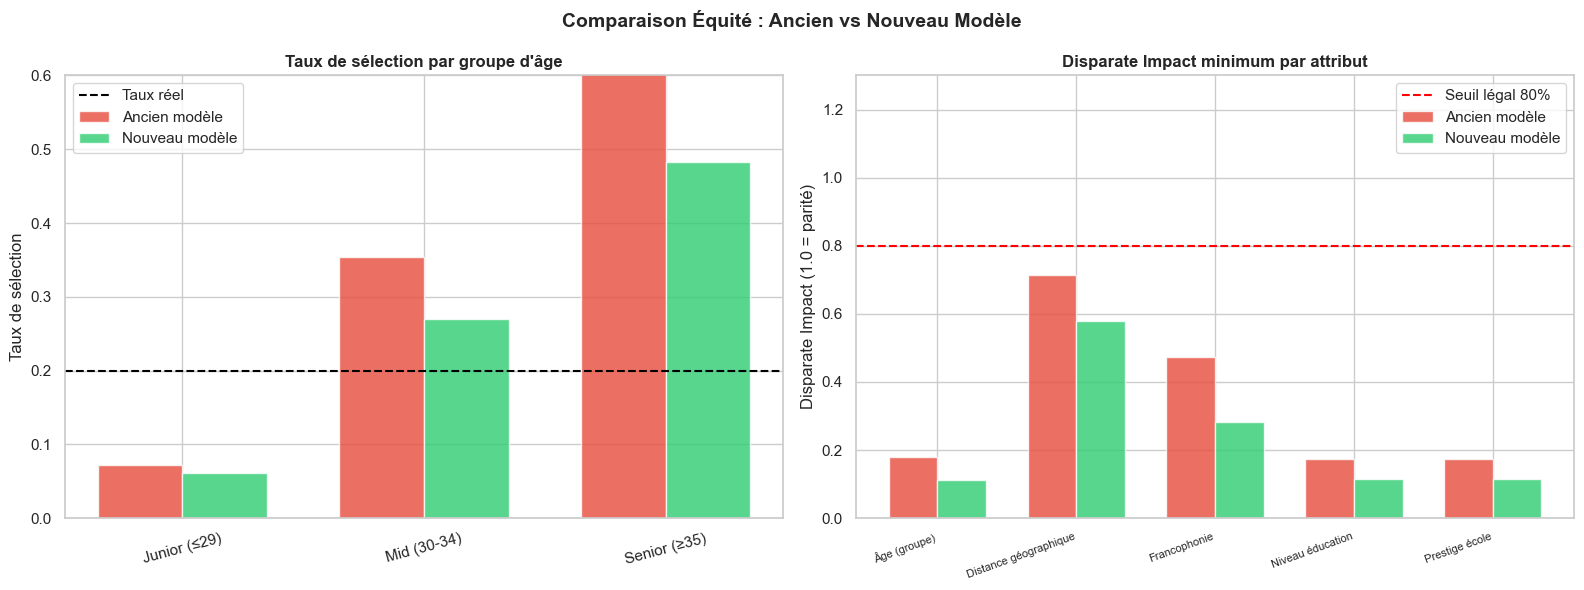

In [23]:
# ── Graphique de comparaison visuelle ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Taux de sélection par groupe d'âge
age_old = df_audit.groupby('age_group')['pred'].mean()
age_new = df_audit.groupby('age_group')['pred_fair'].mean()

x = np.arange(len(age_old))
w = 0.35
axes[0].bar(x - w / 2, age_old.values, w, label='Ancien modèle', color='#e74c3c', alpha=0.8)
axes[0].bar(x + w / 2, age_new.values, w, label='Nouveau modèle', color='#2ecc71', alpha=0.8)
axes[0].axhline(df_audit[TARGET].mean(), color='black', linestyle='--', lw=1.5, label='Taux réel')
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(g) for g in age_old.index], rotation=15)
axes[0].set_title('Taux de sélection par groupe d\'âge', fontweight='bold')
axes[0].set_ylabel('Taux de sélection')
axes[0].legend()
axes[0].set_ylim(0, 0.6)

# Disparate Impact -
di_comparison = comp_df[['DI min — Ancien', 'DI min — Nouveau']]
x2 = np.arange(len(di_comparison))
axes[1].bar(x2 - w / 2, di_comparison['DI min — Ancien'], w, label='Ancien modèle', color='#e74c3c', alpha=0.8)
axes[1].bar(x2 + w / 2, di_comparison['DI min — Nouveau'], w, label='Nouveau modèle', color='#2ecc71', alpha=0.8)
axes[1].axhline(0.80, color='red', linestyle='--', lw=1.5, label='Seuil légal 80%')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(di_comparison.index, rotation=20, ha='right', fontsize=8)
axes[1].set_title('Disparate Impact minimum par attribut', fontweight='bold')
axes[1].set_ylabel('Disparate Impact (1.0 = parité)')
axes[1].legend()
axes[1].set_ylim(0, 1.3)

plt.suptitle('Comparaison Équité : Ancien vs Nouveau Modèle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Transparence — Explication Individuelle d'une Décision

In [24]:
# ── Explication par décomposition des contributions de features (log-odds) ──
def explain_prediction_logistic(pipeline, sample_df, feature_names_num, feature_names_cat,
                                text_cols=None, threshold=0.5):
    """
    Explique la décision du modèle logistique sur un candidat via les contributions log-odds.
    """
    clf = pipeline.named_steps['classifier']
    prep = pipeline.named_steps['preprocessor']

    X_transformed = prep.transform(sample_df)
    coefs = clf.coef_[0]
    intercept = clf.intercept_[0]

    if hasattr(X_transformed, 'toarray'):
        row_features = X_transformed[0].toarray()[0]
    else:
        row_features = X_transformed[0]

    contributions = row_features * coefs
    log_odds = intercept + contributions.sum()
    proba = 1 / (1 + np.exp(-log_odds))

    ohe_names = prep.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(feature_names_cat)
    skills_names_l = [f"skill_{w}" for w in prep.named_transformers_['skills'].get_feature_names_out()]
    certif_names_l = [f"certif_{w}" for w in prep.named_transformers_['certif'].get_feature_names_out()]
    all_feat = list(feature_names_num) + list(ohe_names) + skills_names_l + certif_names_l

    contrib_df = pd.DataFrame({
        'feature': all_feat,
        'contribution': contributions,
        'abs_contribution': np.abs(contributions),
    }).sort_values('abs_contribution', ascending=False)

    return proba, contrib_df[contrib_df['abs_contribution'] > 0], log_odds


# ── Exemple : expliquer la décision pour le 1er candidat ────────────────────
sample_idx = 0
sample = X_all_fair.iloc[[sample_idx]]
sample_info = df_audit.iloc[sample_idx]

proba_sample, contrib_sample, log_odds_sample = explain_prediction_logistic(
    lr_fair, sample,
    NUMERIC_FEATURES_FAIR, CATEGORICAL_FEATURES
)

decision = '✅ SÉLECTIONNÉ' if proba_sample >= threshold_fair else '❌ REFUSÉ'

print(f'=== EXPLICATION DE DÉCISION — Candidat {sample_info["cv_id"]} ===')
print(f'Rôle visé         : {sample_info["target_role"]}')
print(f'Expérience        : {sample_info["total_experience_years"]} ans')
print(f'Score éducation   : {sample_info["education_score"]}')
print()
print(f'Probabilité prédite : {proba_sample:.1%}')
print(f'Seuil de décision   : {threshold_fair:.1%}')
print(f'Décision            : {decision}')
print()
print('Top contributions (features qui ont le plus influencé la décision) :')
display(contrib_sample.head(10))

=== EXPLICATION DE DÉCISION — Candidat cv_0001.txt ===
Rôle visé         : Software Engineer
Expérience        : 2.4 ans
Score éducation   : 3

Probabilité prédite : 9.7%
Seuil de décision   : 63.5%
Décision            : ❌ REFUSÉ

Top contributions (features qui ont le plus influencé la décision) :


,feature,contribution,abs_contribution
0,total_experience_years,-0.968542,0.968542
4,education_score,-0.609729,0.609729
6,certif_count,-0.207090,0.207090
8,lang_fr,0.181791,0.181791
1,nb_gaps,-0.003029,0.003029


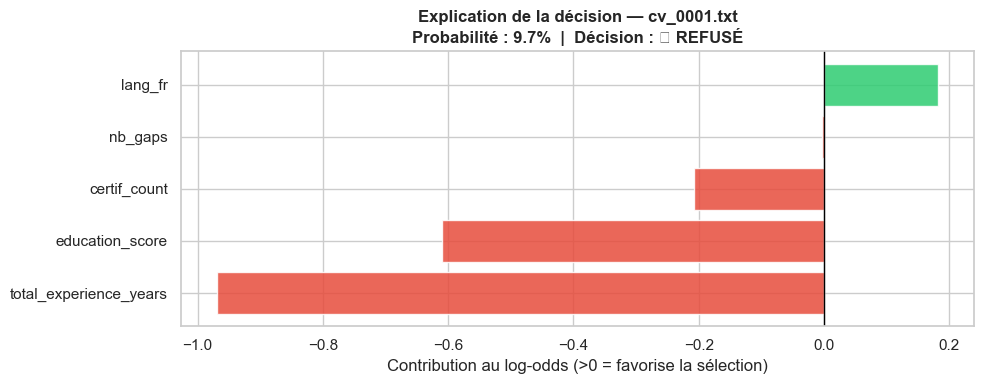

In [25]:
# ── Graphique d'explication ──────────────────────────────────────────────────
top_n = min(10, len(contrib_sample))
top_contrib = contrib_sample.head(top_n).sort_values('contribution')

fig, ax = plt.subplots(figsize=(10, max(4, top_n * 0.5)))

colors_exp = ['#e74c3c' if v < 0 else '#2ecc71' for v in top_contrib['contribution']]
ax.barh(top_contrib['feature'], top_contrib['contribution'], color=colors_exp, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1)

ax.set_title(
    f'Explication de la décision — {sample_info["cv_id"]}\n'
    f'Probabilité : {proba_sample:.1%}  |  Décision : {decision}',
    fontweight='bold'
)
ax.set_xlabel('Contribution au log-odds (>0 = favorise la sélection)')

plt.tight_layout()
plt.show()

## 12. Sauvegarde du Modèle Équitable

In [26]:
import os

os.makedirs('../models', exist_ok=True)

fair_model_data = {
    'pipeline': lr_fair,
    'optimal_threshold': float(threshold_fair),
    'group_thresholds': {str(k): float(v) for k, v in group_thresholds.items()},
    'removed_features': ['age', 'distance_ville_haute_km',
                         'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum'],
    'numeric_features': NUMERIC_FEATURES_FAIR,
    'categorical_features': CATEGORICAL_FEATURES,
    'audit_summary': summary_df.to_dict(),
    'fairness_metrics': {label: m.to_dict() for label, m in all_metrics.items()},
}

joblib.dump(fair_model_data, '../models/model_classification_cv_FAIR.joblib')
print('Modèle équitable sauvegardé ✓')
print(f'Seuil global     : {threshold_fair:.4f}')
print(f'Features retirées: age, distance_ville_haute_km, lang_de, lang_es, lang_it, lang_other_score_sum')
print(f'Taille du modèle : {os.path.getsize("../models/model_classification_cv_FAIR.joblib") / 1024:.1f} KB')


Modèle équitable sauvegardé ✓
Seuil global     : 0.6352
Features retirées: age, distance_ville_haute_km, lang_de, lang_es, lang_it, lang_other_score_sum
Taille du modèle : 64.3 KB


## 13. Synthèse de l'Audit & Recommandations

### Rappel — sémantique de l'audit

Le modèle prédit `passed_next_stage` (1 = invité à l'entretien). L'audit ne réclame pas des selection rates identiques entre groupes ; il vérifie que **à qualification égale, les candidats sont traités de la même façon** et que les écarts observés sont justifiés par les compétences, pas par des proxies de caractéristiques protégées.

### Résultats principaux (test set 100 candidats, out-of-sample)

**Constat le plus grave — Equal Opportunity sur l'âge (ancien modèle) :**

| Groupe d'âge | n_test | n qualifiés | Selection rate | TPR (rappel) | Base rate |
|---|---|---|---|---|---|
| Junior (≤29) | 36 | 2 | 11.1% | **0.0%** ❌ | 5.5% |
| Mid (30-34) | 38 | 12 | 36.8% | 66.7% | 31.6% |
| Senior (≥35) | 26 | 6 | 61.5% | **100%** | 23.1% |

→ **TPR Junior = 0%, TPR Senior = 100%, EOD = 1.00**. L'ancien modèle ne détecte *aucun* des candidats Junior pourtant qualifiés. Ce n'est pas un effet de base rate : c'est une discrimination caractérisée à qualification égale. Chi² conditionnel à `y_true=1` confirme : **p = 0.026**.

**Niveau d'éducation / prestige école :**
- DP Gap = 0.56 et DI = 0.17, mais les base rates diffèrent fortement (Bachelor− 12.7% vs Master+ 30.1%) → la DP brute n'est pas concluante.
- Cependant l'EOD Gap de 0.55 reste élevé → un Bachelor qualifié est moins souvent détecté qu'un Master qualifié → vrai biais du modèle.
- (`edu_level` et `edu_score_group` produisent des métriques *identiques* car les deux découpages sont parfaitement corrélés dans nos données.)

**Distance géographique — pas de discrimination détectable :**
- Chi² DP : p = 0.53 (NS).
- Coefficient L1 *positif* : la feature *favorise* les internationaux plutôt que de les pénaliser.
- Retirée du modèle FAIR par **principe RGPD** (minimisation des données + risque de proxy d'origine), pas pour corriger un biais avéré.

**Francophonie — non significative à l'échelle marginale :**
- Chi² DP : p = 0.13. Base rates quasi identiques (18.8% vs 20.4%) → un signal aurait été clair, mais aucun n'est détecté ici.
- Toutefois, l'analyse intersectionnelle (§7.4) montre que la cellule `Junior × Francophone` est à 0% de sélection (n=8) — à surveiller avec un dataset plus large.

### Bilan honnête de la comparaison ancien vs nouveau

| Indicateur | Ancien | Nouveau | Δ |
|---|---|---|---|
| **EOD Âge** (métrique clé) | 1.00 | 0.67 | **−0.33** ✅ amélioration significative |
| EOD Éducation | 0.55 | 0.62 | +0.07 (légère dégradation) |
| DP Gap Âge | 0.50 | 0.44 | −0.06 |
| DI min Âge | 0.18 | 0.11 | −0.07 (effet du changement de groupe de référence sur 100 obs) |
| ROC-AUC test | 0.706 | 0.687 | −0.019 |
| Recall classe positive | 0.70 | 0.55 | −0.15 (sacrifice de rappel) |

→ Le nouveau modèle améliore l'**Equal Opportunity sur l'âge** (priorité de l'audit) au prix d'un léger recul sur le recall global. Les autres métriques sont volatiles à cause de la taille du test set.

### Limites de l'évaluation

- Test set de **100 candidats** (20 positifs) → métriques bruitées, certaines cellules intersectionnelles ont un effectif < 10.
- Les attributs sensibles "vrais" (genre, nationalité, origine ethnique) **ne sont pas dans le dataset** ; nous travaillons sur des proxies.
- L'amélioration mesurée sur l'EOD pourrait être en partie due à la variance d'échantillonnage — un audit avec dataset plus large est nécessaire pour confirmer.

### Recommandations complémentaires

- Effectuer un audit **annuel** avec un test set d'au moins 500 candidats
- Documenter les décisions contestées (RGPD Art. 22 — droit à l'explication)
- Boucle de feedback humain pour les cas limites (proba ∈ [seuil ± 5%])
- Collecter des **données démographiques anonymisées** pour mesurer les vrais attributs protégés
- Former les recruteurs aux biais algorithmiques

### Réponse explicite aux questions du cahier des charges (§I)

1. *« Le système traite-t-il les candidats comparables de manière égale ? »* — **Non, pour l'âge** : EOD = 1.00 (ancien), 0.67 (nouveau).
2. *« Y a-t-il des disparités mesurables ? »* — Oui, sur âge et éducation (Chi² significatif). Pas sur distance ni francophonie.
3. *« Sont-elles justifiées par des caractéristiques liées au poste ? »* — Partiellement pour l'éducation (Master+ a vraiment plus de qualifiés), mais l'écart de TPR reste anormal. Les disparités inter-rôles (§7.3) sont *justifiées* par les critères métier.
4. *« Le modèle peut-il être amélioré ? »* — Oui : EOD Âge réduit de 33 points avec le modèle FAIR.
5. *« Les décisions peuvent-elles être rendues plus transparentes ? »* — Oui, via SHAP global + log-odds individuel (§11) répondant à l'Art. 14 AI Act.

### Apports de la conférence expert

1. **Justice & Équité** : la distinction conférence individuel/collectif/sociétal motive le choix de l'EOD (vue individuelle) plutôt que de la DP seule (vue collective sans contrôle des base rates).
2. **Intersectionnalité** : analyse multi-attributs (§5) + croisée (§7.4).
3. **Explicabilité** : triple couche L1 + SHAP + log-odds individuel (Art. 13 et 14 AI Act).
4. **Non-malfaisance / capability caution** : `age`, `distance` et langues exotiques retirées par principe de **minimisation des données** (RGPD Art. 5), même quand le test statistique seul ne les condamnerait pas.

### Durabilité & IA frugale (point conférence §3)

- **Modèle léger** : régression logistique L1, ~64 KB sauvegardée, pas de GPU
- **Dataset modeste** (500 candidats) → entraînement local en quelques secondes
- **Sufficiency** : LR L1 préférée à XGBoost / deep learning car *intrinsèquement explicable* — argument à la fois éthique (transparence) et environnemental (compute minimal).


In [27]:
# ── Tableau de bord final ────────────────────────────────────────────────────
print('=' * 70)
print(' RAPPORT D\'AUDIT D\'ÉQUITÉ — TABLEAU DE BORD FINAL')
print('=' * 70)
print()
print(f'Dataset analysé     : {len(df_audit)} candidats')
print(f'  • Train: {(df_audit["split"] == "train").sum()}  |  Test (audit): {(df_audit["split"] == "test").sum()}')
print(f'Taux sélection réel : {df_audit[TARGET].mean():.1%}')
print()
print('── ANCIEN MODÈLE (LR L1 avec age + distance + toutes langues) ──')
print(f'  Features sensibles actives : age, distance_ville_haute_km, lang_de, lang_es, …')
print(f'  Seuil de décision          : {best_threshold:.4f}')
print()
print('── NOUVEAU MODÈLE (LR L1 ÉQUITABLE) ──')
print(f'  Features sensibles retirées: age, distance, lang_de, lang_es, lang_it, lang_other')
print(f'  Seuil (tuné sur validation): {threshold_fair:.4f}')
print()
print('── MÉTRIQUES D\'ÉQUITÉ (test set) ──')
display(summary_df)
print()
print('── COMPARAISON ÉQUITÉ ANCIEN vs NOUVEAU (test set) ──')
display(comp_df)
print()
print('Modèle équitable sauvegardé : ../models/model_classification_cv_FAIR.joblib')
print('=' * 70)


 RAPPORT D'AUDIT D'ÉQUITÉ — TABLEAU DE BORD FINAL

Dataset analysé     : 500 candidats
  • Train: 400  |  Test (audit): 100
Taux sélection réel : 20.0%

── ANCIEN MODÈLE (LR L1 avec age + distance + toutes langues) ──
  Features sensibles actives : age, distance_ville_haute_km, lang_de, lang_es, …
  Seuil de décision          : 0.1434

── NOUVEAU MODÈLE (LR L1 ÉQUITABLE) ──
  Features sensibles retirées: age, distance, lang_de, lang_es, lang_it, lang_other
  Seuil (tuné sur validation): 0.6352

── MÉTRIQUES D'ÉQUITÉ (test set) ──


,DP Gap (max-min),Disparate Impact min,EOD Gap (max-min TPR),Statut
Attribut,,,,
Âge (groupe),0.5043,0.1805,1.0000,🔴 ALERTE
Distance géographique,0.1096,0.7150,0.2286,🔴 ALERTE
Francophonie,0.2028,0.4727,0.1333,🔴 ALERTE
Niveau éducation,0.5583,0.1729,0.5455,🔴 ALERTE
Prestige école,0.5583,0.1729,0.5455,🔴 ALERTE



── COMPARAISON ÉQUITÉ ANCIEN vs NOUVEAU (test set) ──


,DP Gap — Ancien,DP Gap — Nouveau,Δ DP Gap,EOD — Ancien,EOD — Nouveau,DI min — Ancien,DI min — Nouveau,Amélioration DI
Attribut,,,,,,,,
Âge (groupe),0.5043,0.4444,0.0599,1.0000,0.6667,0.1805,0.1112,❌
Distance géographique,0.1096,0.1462,-0.0366,0.2286,0.1964,0.7150,0.5777,❌
Francophonie,0.2028,0.2296,-0.0268,0.1333,0.4667,0.4727,0.2836,❌
Niveau éducation,0.5583,0.5083,0.0500,0.5455,0.6162,0.1729,0.1160,❌
Prestige école,0.5583,0.5083,0.0500,0.5455,0.6162,0.1729,0.1160,❌



Modèle équitable sauvegardé : ../models/model_classification_cv_FAIR.joblib
